# Исследование объявлений о продаже квартир

В вашем распоряжении данные сервиса Яндекс Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет. Вам нужно научиться определять рыночную стоимость объектов недвижимости. Для этого проведите исследовательский анализ данных и установите параметры, влияющие на цену объектов. Это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность.

По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных. Например, расстояние до центра, аэропорта и других объектов — эти данные автоматически получены из геосервисов. Количество парков и водоёмов также заполняется без участия пользователя.

***Цель:***
выяснить, какие параметры влияют на рыночную стоимость объектов недвижимости, в целях автоматизации процесса определения мошеннической деятельности.

***План работ:***

**Шаг 1. Открыть файл с данными и изучить общую информацию** 
- Загрузиь данные из csv-файла в датафрейм c помощью библиотеки pandas;
- Изучить общую информацию о полученном датафрейме;
- Построить гистограмму для всех числовых столбцов таблицы на одном графике;

**Шаг 2. Выполнить предобработку данных** \
2.1 Найти и изучить пропущенные значения в столбцах:
- определить, в каких столбцах есть пропуски
- заполнить пропущенные значения там, где это возможно
- указать причины, которые могли привести к пропускам в данных
  
2.2 Рассмотреть типы данных в каждом столбце:
- найти столбцы, в которых нужно изменить тип данных, преобразовать их
- пояснить, почему нужно изменить тип данных
  
2.3 Изучить уникальные значения в столбце с названиями и устранить неявные дубликаты.

**Шаг 3. Добавить в таблицу новые столбцы со следующими параметрами:** 
- цена одного квадратного метра
- день недели публикации объявления (0 — понедельник, 1 — вторник и так далее)
- месяц публикации объявления
- год публикации объявления
- тип этажа квартиры (значения — «первый», «последний», «другой»)
- расстояние до центра города в километрах (перевести из м в км и округлить до ближайших целых значений)

**Шаг 4. Провести исследовательский анализ данных:** 

4.1 Изучить перечисленные ниже параметры объектов и построить отдельные гистограммы для каждого из этих параметров. Удалить аномалии если она есть и восстановить корректное значениев столбце ceiling_height. Описать все наблюдения по параметрам в ячейке с типом markdown.
Список параметров:
общая площадь;
жилая площадь;
площадь кухни;
цена объекта;
количество комнат;
высота потолков;
тип этажа квартиры («первый», «последний», «другой»);
общее количество этажей в доме;
расстояние до центра города в метрах;
расстояние до ближайшего парка 

4.2 Изучить скорость продажи квартиры (столбец days_exposition). Этот параметр показывает, сколько дней было размещено каждое объявление.
- Построитьт гистограмму
- Посчитать среднее и медиану
- описать сколько времени обычно занимает продажа. Какие продажи можно считать быстрыми, а какие — необычно долгими

4.3 Определить факторы, которые больше всего влияют на общую (полную) стоимость объекта. 

Изучить, зависит ли цена от:
общей площади;
жилой площади;
площади кухни;
количества комнат;
этажа, на котором расположена квартира (первый, последний, другой);
даты размещения (день недели, месяц, год). 

Построить графики, которые покажут зависимость цены от указанных выше параметров.  

4.4 Посчитать среднюю цену одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений — построить сводную таблицу с количеством объявлений и средней ценой квадратного метра для этих населенных пунктов. Выделить населённые пункты с самой высокой и низкой стоимостью квадратного метра. 

4.5 Выделить квартиры в Санкт-Петербурге с помощью столбца locality_name и вычислить их среднюю стоимость на разном удалении от центра в км - для каждого км. Описать, как стоимость объектов зависит от расстояния до центра города — построить график изменения средней цены для каждого километра от центра Петербурга.

**Шаг 5. Написать общий вывод** 

Описать полученные результаты и зафиксировать итоговый вывод проведённого исследования.


## Шаг 1. Открыть файл с данными и изучить общую информацию

In [1]:
import pandas as pd # импортирт библиотеки pandas
import matplotlib.pyplot as plt # импортирт библиотеки matplotlib

In [2]:
try: 
    data = pd.read_csv("real_estate_data.csv", sep='\t')
except:
    data = pd.read_csv("/datasets/real_estate_data.csv", sep='\t')
data.head(20)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.00,2019-03-07T00:00:00,3,2.70,16.0,51.00,8,NaN,...,25.00,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.40,2018-12-04T00:00:00,1,NaN,11.0,18.60,1,NaN,...,11.00,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.00,2015-08-20T00:00:00,2,NaN,5.0,34.30,4,NaN,...,8.30,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.00,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,...,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.00,2018-06-19T00:00:00,2,3.03,14.0,32.00,13,NaN,...,41.00,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0
5,10,2890000.0,30.40,2018-09-10T00:00:00,1,NaN,12.0,14.40,5,NaN,...,9.10,NaN,городской посёлок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.0
6,6,3700000.0,37.30,2017-11-02T00:00:00,1,NaN,26.0,10.60,6,NaN,...,14.40,1.0,посёлок Парголово,52996.0,19143.0,0.0,NaN,0.0,NaN,155.0
7,5,7915000.0,71.60,2019-04-18T00:00:00,2,NaN,24.0,NaN,22,NaN,...,18.90,2.0,Санкт-Петербург,23982.0,11634.0,0.0,NaN,0.0,NaN,NaN
8,20,2900000.0,33.16,2018-05-23T00:00:00,1,NaN,27.0,15.43,26,NaN,...,8.81,NaN,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.0
9,18,5400000.0,61.00,2017-02-26T00:00:00,3,2.50,9.0,43.60,7,NaN,...,6.50,2.0,Санкт-Петербург,50898.0,15008.0,0.0,NaN,0.0,NaN,289.0


In [3]:
data.info() # общая информацию датафрейма

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

Выяснили, что срок всего 23699. Необходимо будет изменть тип данных столбцам: 

    - на int: 'last_price', 'floors_total', 'parks_around3000', 'ponds_around3000', 'days_exposition'.
    
    - на datetime: 'first_day_exposition'.
    
    - на bool: 'is_apartment', 'balcony'.

In [4]:
data.duplicated().sum() # число дубликатов 

0

In [5]:
data.describe() # описательная статистика датафрейма по столбцам

,total_images,last_price,total_area,rooms,ceiling_height,floors_total,living_area,floor,kitchen_area,balcony,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
count,23699.000000,2.369900e+04,23699.000000,23699.000000,14504.000000,23613.000000,21796.000000,23699.000000,21421.000000,12180.000000,18157.000000,18180.000000,18181.000000,8079.000000,18181.000000,9110.000000,20518.000000
mean,9.858475,6.541549e+06,60.348651,2.070636,2.771499,10.673824,34.457852,5.892358,10.569807,1.150082,28793.672193,14191.277833,0.611408,490.804555,0.770255,517.980900,180.888634
std,5.682529,1.088701e+07,35.654083,1.078405,1.261056,6.597173,22.030445,4.885249,5.905438,1.071300,12630.880622,8608.386210,0.802074,342.317995,0.938346,277.720643,219.727988
min,0.000000,1.219000e+04,12.000000,0.000000,1.000000,1.000000,2.000000,1.000000,1.300000,0.000000,0.000000,181.000000,0.000000,1.000000,0.000000,13.000000,1.000000
25%,6.000000,3.400000e+06,40.000000,1.000000,2.520000,5.000000,18.600000,2.000000,7.000000,0.000000,18585.000000,9238.000000,0.000000,288.000000,0.000000,294.000000,45.000000
50%,9.000000,4.650000e+06,52.000000,2.000000,2.650000,9.000000,30.000000,4.000000,9.100000,1.000000,26726.000000,13098.500000,0.000000,455.000000,1.000000,502.000000,95.000000
75%,14.000000,6.800000e+06,69.900000,3.000000,2.800000,16.000000,42.300000,8.000000,12.000000,2.000000,37273.000000,16293.000000,1.000000,612.000000,1.000000,729.000000,232.000000
max,50.000000,7.630000e+08,900.000000,19.000000,100.000000,60.000000,409.700000,33.000000,112.000000,5.000000,84869.000000,65968.000000,3.000000,3190.000000,3.000000,1344.000000,1580.000000


Присутствуют очень сомнительные данные: такие максимальные параметры как кол-во комнат 19 и высота потолков 100 м.

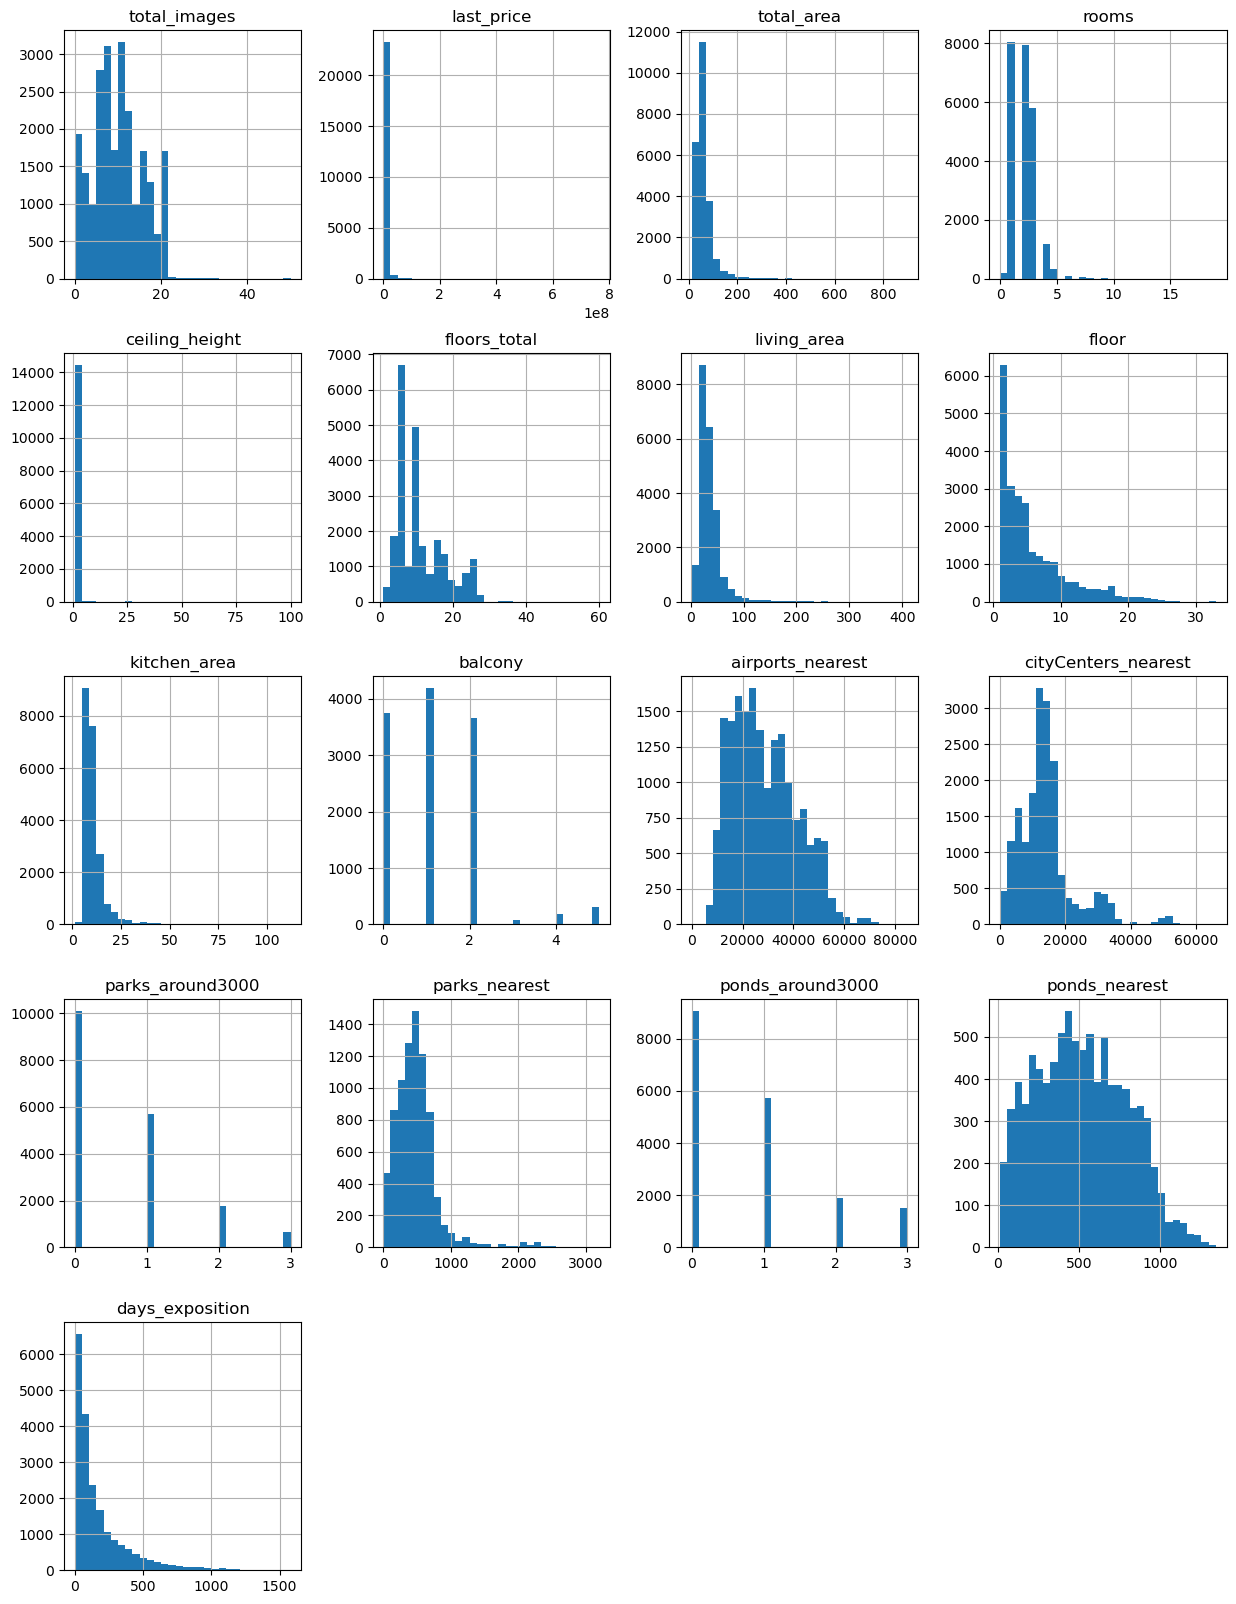

In [6]:
data.hist(figsize=(15, 20), bins=30); # гистограмма для всех числовых столбцов

**Вывод:**

Выяснили, что срок всего 23699. Присутствуют аномальные значения, пропуски и некорректный тип данных по некоторым столбцам. Явные дубликаты отсутствуют. 

## Шаг 2. Выполните предобработку данных

In [7]:
print(data.isna().sum()) #количество пропущенных значений для каждого столбца 

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment            20924
studio                      0
open_plan                   0
kitchen_area             2278
balcony                 11519
locality_name              49
airports_nearest         5542
cityCenters_nearest      5519
parks_around3000         5518
parks_nearest           15620
ponds_around3000         5518
ponds_nearest           14589
days_exposition          3181
dtype: int64


In [8]:
all = (data.isnull().sum ()/ len(data))* 100 # процент пропусков в столбцах
all

total_images             0.000000
last_price               0.000000
total_area               0.000000
first_day_exposition     0.000000
rooms                    0.000000
ceiling_height          38.799105
floors_total             0.362885
living_area              8.029875
floor                    0.000000
is_apartment            88.290645
studio                   0.000000
open_plan                0.000000
kitchen_area             9.612220
balcony                 48.605426
locality_name            0.206760
airports_nearest        23.384953
cityCenters_nearest     23.287902
parks_around3000        23.283683
parks_nearest           65.909954
ponds_around3000        23.283683
ponds_nearest           61.559559
days_exposition         13.422507
dtype: float64

In [9]:
missing_values = data.isnull().sum() #кол-во пропущенных значений в столбцах
total_missing = missing_values.sum() #кол-во пропущенных значений во всем датасете 
total_cells = data.size #кол-во ячеек во всем датасете 
missing_ratio = total_missing / total_cells 
missing_ratio 

0.1945632535319864

Во всем датасете примерно 19% пропусков.

total_images                - без поправок \
last_price                  - изменить тип данных на int64 \
total_area                  - без поправок \
first_day_exposition        - изменить тип данных на datetime
rooms                       - без поправок \
ceiling_height              - пропуски: заменить медианным значением в зависимости от населенного пункта \
floors_total                - пропуски: удалить, т.к. их мало; изменить тип данных на int64 \
living_area                 - пропуски: переумнажая общую площадь на среднюю долю жилой \
floor                       - без поправок \
is_apartment                - пропуски: заменить на False; изменить тип данных на bool \
studio                      - без поправок \
open_plan                   - без поправок \
kitchen_area                - пропуски: переумнажая общую площадь на среднюю долю кухни \
balcony                     - пропуски: заменить на 0; изменить тип данных на bool \
locality_name               - пропуски: удалить, т.к. их мало \
airports_nearest            - пропуски: заменить медианным значением в зависимости от населенного пункта, остальные - оставить \
cityCenters_nearest         - пропуски: заменить медианным значением в зависимости от населенного пункта, остальные - оставить  \
parks_around3000            - пропуски: заменить медианным значением в зависимости от населенного пункта, остальные - оставить ; изменить тип данных на int64 \
parks_nearest               - пропуски: заменить медианным значением в зависимости от населенного пункта, остальные - оставить  \
ponds_around3000            - пропуски: заменить медианным значением в зависимости от населенного пункта, остальные - оставить ; изменить тип данных на int64 \
ponds_nearest               - пропуски: заменить медианным значением в зависимости от населенного пункта, остальные - оставить  \
days_exposition             - пропуски: оставила; изменить тип данных на int64 

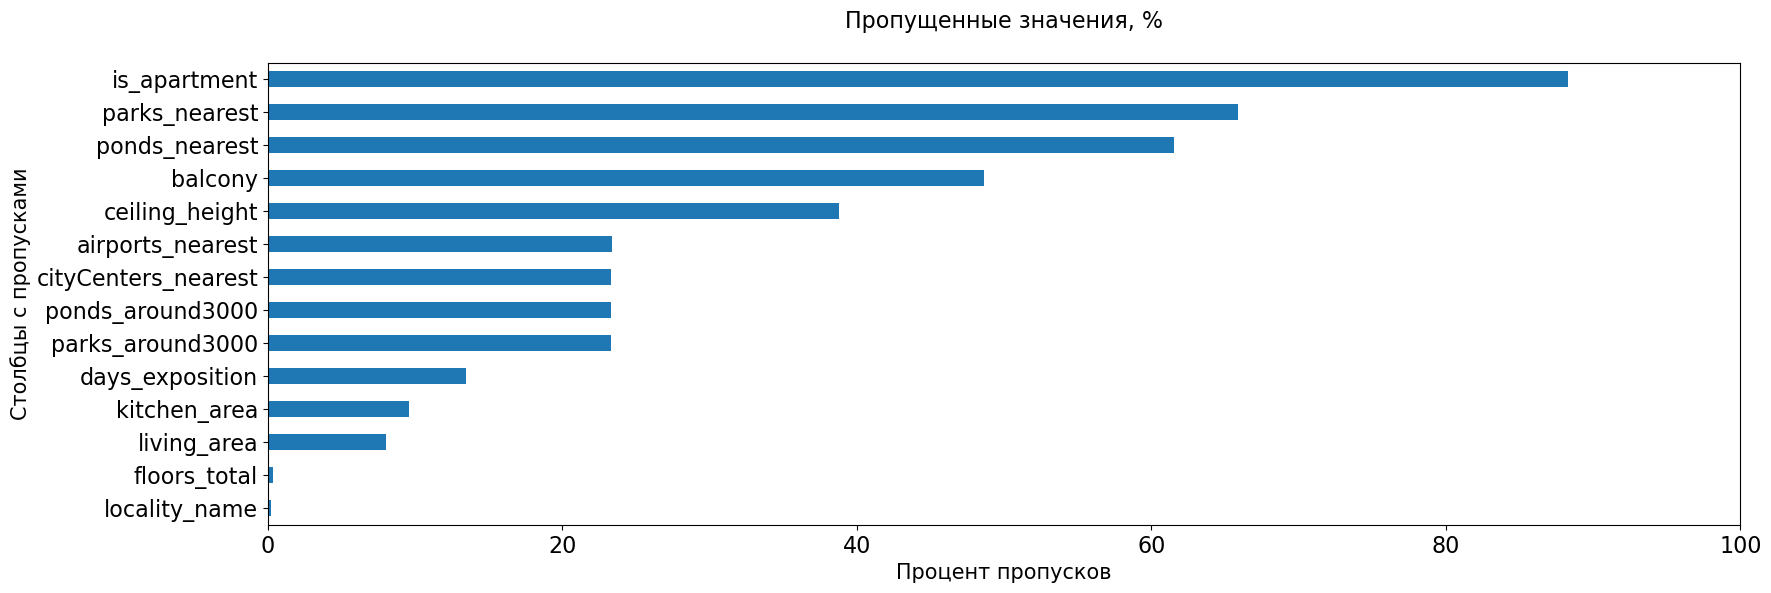

In [10]:
def pass_value_barh(dfg):
    try:
        (
            (dfg.isna().mean()*100)
            .to_frame()
            .rename(columns = {0:'space'})
            .query('space > 0')
            .sort_values(by = 'space', ascending = True)
            .plot(kind = 'barh', figsize = (19,6), rot = 0, legend = False, fontsize = 16)         
        ); 
        plt.title('Пропущенные значения, %' + "\n", fontsize=16)
        plt.xlabel('Процент пропусков', fontsize=15)
        plt.ylabel('Столбцы с пропусками', fontsize=15)  
        plt.xlim(0, 100) 
    except:
        print('пропусков не осталось :) или произошла ошибка в первой части функции ')
pass_value_barh(data)

In [11]:
data = data.rename(columns = {'cityCenters_nearest':'city_centers_nearest'}) #переименование название столбца 

In [12]:
data['last_price'] = data['last_price'].astype('int') #изменен тип данных на int
data['last_price']

0        13000000
1         3350000
2         5196000
3        64900000
4        10000000
           ...   
23694     9700000
23695     3100000
23696     2500000
23697    11475000
23698     1350000
Name: last_price, Length: 23699, dtype: int32

Столбец с прайсом перевела в целочисленный тип данных.

In [13]:
#переведены строки в тип datetime для дальнейшей работы с датами 
data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'], format='%Y-%m-%dT%H:%M:%S') 
data['first_day_exposition'].head(10)

0   2019-03-07
1   2018-12-04
2   2015-08-20
3   2015-07-24
4   2018-06-19
5   2018-09-10
6   2017-11-02
7   2019-04-18
8   2018-05-23
9   2017-02-26
Name: first_day_exposition, dtype: datetime64[ns]

Столбец с датами публикации перевела в соответсвующий тип данных - дата.

In [14]:
data['is_apartment'] = data['is_apartment'].fillna(False) #изменен тип данных на bool
print(data['is_apartment'].head())
data['is_apartment'].value_counts()

0    False
1    False
2    False
3    False
4    False
Name: is_apartment, dtype: bool


is_apartment
False    23649
True        50
Name: count, dtype: int64

Если продавец не указал тип помещения как апартаменты, следовательно, можно предположить, что пропуски - это не апартаменты. Продавец апартаментов скорее всего знал бы, что у него апартаменты. Заменила пропуски на False - тип данных bool. Видим, что апартаментов всего 50.

In [15]:
#заменены все пропуски в столбце'balcony' на 0 и изменен тип данных на int
data['balcony'] = data['balcony'].fillna(0).astype('int')
data['balcony']

0        0
1        2
2        0
3        0
4        0
        ..
23694    0
23695    0
23696    0
23697    2
23698    0
Name: balcony, Length: 23699, dtype: int32

Если продавец не указал число балконов, то, скорее всего, в его квартире их нет. Такие пропуски можно заменить на число 0. Столбец перевела в целочисленный тип данных.

In [16]:
data['locality_name'].unique()

array(['Санкт-Петербург', 'посёлок Шушары', 'городской посёлок Янино-1',
       'посёлок Парголово', 'посёлок Мурино', 'Ломоносов', 'Сертолово',
       'Петергоф', 'Пушкин', 'деревня Кудрово', 'Коммунар', 'Колпино',
       'поселок городского типа Красный Бор', 'Гатчина', 'поселок Мурино',
       'деревня Фёдоровское', 'Выборг', 'Кронштадт', 'Кировск',
       'деревня Новое Девяткино', 'посёлок Металлострой',
       'посёлок городского типа Лебяжье',
       'посёлок городского типа Сиверский', 'поселок Молодцово',
       'поселок городского типа Кузьмоловский',
       'садовое товарищество Новая Ропша', 'Павловск',
       'деревня Пикколово', 'Всеволожск', 'Волхов', 'Кингисепп',
       'Приозерск', 'Сестрорецк', 'деревня Куттузи', 'посёлок Аннино',
       'поселок городского типа Ефимовский', 'посёлок Плодовое',
       'деревня Заклинье', 'поселок Торковичи', 'поселок Первомайское',
       'Красное Село', 'посёлок Понтонный', 'Сясьстрой', 'деревня Старая',
       'деревня Лесколово', '

Вывела перечень уникальных значений названий населенных пунктов, где видны явные дубликаты.

In [17]:
data['locality_name'] = data['locality_name'].str.replace('ё', 'е')\
    .replace(['поселок городского типа', 'городской поселок', 'коттеджный поселок'], 'поселок', regex=True)
data['locality_name'].unique()

array(['Санкт-Петербург', 'поселок Шушары', 'поселок Янино-1',
       'поселок Парголово', 'поселок Мурино', 'Ломоносов', 'Сертолово',
       'Петергоф', 'Пушкин', 'деревня Кудрово', 'Коммунар', 'Колпино',
       'поселок Красный Бор', 'Гатчина', 'деревня Федоровское', 'Выборг',
       'Кронштадт', 'Кировск', 'деревня Новое Девяткино',
       'поселок Металлострой', 'поселок Лебяжье', 'поселок Сиверский',
       'поселок Молодцово', 'поселок Кузьмоловский',
       'садовое товарищество Новая Ропша', 'Павловск',
       'деревня Пикколово', 'Всеволожск', 'Волхов', 'Кингисепп',
       'Приозерск', 'Сестрорецк', 'деревня Куттузи', 'поселок Аннино',
       'поселок Ефимовский', 'поселок Плодовое', 'деревня Заклинье',
       'поселок Торковичи', 'поселок Первомайское', 'Красное Село',
       'поселок Понтонный', 'Сясьстрой', 'деревня Старая',
       'деревня Лесколово', 'поселок Новый Свет', 'Сланцы',
       'село Путилово', 'Ивангород', 'Мурино', 'Шлиссельбург',
       'Никольское', 'Зелено

С помощью метода replace() заменяем альтернативные написания на одно правильное значение.

In [18]:
data.query('locality_name in ["деревня Кудрово", "Кудрово"]').head(20)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
22,20,5000000,58.00,2017-04-24,2,2.75,25.0,30.00,15,False,...,11.00,2,деревня Кудрово,NaN,NaN,NaN,NaN,NaN,NaN,60.0
333,10,5800000,57.00,2017-08-30,2,2.76,18.0,29.00,3,False,...,13.00,0,деревня Кудрово,NaN,NaN,NaN,NaN,NaN,NaN,122.0
349,4,2320000,25.00,2017-09-27,0,NaN,14.0,17.00,1,False,...,NaN,0,деревня Кудрово,NaN,NaN,NaN,NaN,NaN,NaN,45.0
369,20,4440000,41.40,2018-11-18,1,2.70,18.0,16.70,10,False,...,10.90,0,Кудрово,NaN,NaN,NaN,NaN,NaN,NaN,NaN
515,7,5500000,51.40,2018-09-06,2,2.60,14.0,29.10,11,False,...,9.30,1,Кудрово,NaN,NaN,NaN,NaN,NaN,NaN,60.0
615,15,4100000,43.00,2017-06-30,1,NaN,18.0,10.00,12,False,...,20.00,2,деревня Кудрово,NaN,NaN,NaN,NaN,NaN,NaN,18.0
631,6,4990000,55.00,2016-08-08,2,NaN,16.0,32.00,15,False,...,11.00,0,деревня Кудрово,NaN,NaN,NaN,NaN,NaN,NaN,557.0
685,7,2800000,33.00,2016-01-11,1,2.55,27.0,16.00,1,False,...,8.40,0,деревня Кудрово,NaN,NaN,NaN,NaN,NaN,NaN,303.0
689,5,3500000,32.60,2017-05-22,1,2.70,18.0,16.11,5,False,...,9.57,0,деревня Кудрово,NaN,NaN,NaN,NaN,NaN,NaN,325.0
697,12,2500000,24.10,2017-12-01,0,2.75,25.0,17.50,21,False,...,NaN,0,деревня Кудрово,NaN,NaN,NaN,NaN,NaN,NaN,201.0


Названия 'деревня Кудрово' и 'Кудрово' я бы не стала объединить, так как формально 'деревня Кудрово' стала городом с 2018 года. Статус города сказался на повышение цен.

In [19]:
data.duplicated().sum() # повторная проверка на дубликаты после обработки неявных дубликатов

0

In [20]:
data[data.duplicated(subset=['locality_name', 'first_day_exposition', 'floors_total', 'floor', 'total_area', 'city_centers_nearest', 'rooms'], keep=False)]


,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
1809,6,5400000,68.8,2018-11-16,2,2.75,22.0,35.55,16,False,...,13.67,0,поселок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,24.0
11117,6,6812033,60.4,2018-07-24,2,3.00,4.0,NaN,2,False,...,10.44,5,Санкт-Петербург,44870.0,20802.0,0.0,NaN,1.0,792.0,219.0
12376,3,18206548,139.5,2018-07-04,4,3.30,16.0,82.55,9,False,...,13.84,0,Санкт-Петербург,37434.0,8460.0,1.0,441.0,2.0,427.0,NaN
14886,6,7433186,60.4,2018-07-24,2,3.00,4.0,NaN,2,False,...,10.94,5,Санкт-Петербург,44870.0,20802.0,0.0,NaN,1.0,792.0,NaN
18579,1,5400043,68.8,2018-11-16,2,2.75,22.0,35.55,16,False,...,13.67,0,поселок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,20.0
23516,3,22529250,139.5,2018-07-04,4,3.30,16.0,82.55,9,False,...,13.84,0,Санкт-Петербург,37434.0,8460.0,1.0,441.0,2.0,427.0,266.0


Нашлись 3 пары одинаковых квартир. У одной пары цены одинаковые, а двух других пар есть разница в ценах.

In [21]:
share_name = (data['locality_name'].isna().sum()/ len(data))* 100
share_name

0.20675977889362418

Доля пропусков в в столбце 'locality_name' меньше 1%, следовательно, эти пропуски можно удалить. Скорее всего пользователь забыл заполнить данный параметр, например указав только улицу.

In [22]:
data.dropna(subset=['locality_name'], inplace=True) #удаление остальных пропусков
data['locality_name'].isna().sum()

0

In [23]:
def categorize_name(row): # создание функции с условиями категоризации
    if 'Санкт-Петербург' in row:
        return 'Санкт-Петербург'
    elif 'поселок' in row:
         return 'поселок'
    elif 'деревня' in row:
         return 'деревня'
    elif 'село' in row:
         return 'село'
    else:
        return 'другие города'
data['name'] = data['locality_name'].apply(categorize_name) #добавление столбца 'name' с категоризацией населенного пункта
data['name'].value_counts() #перечень категорий районов и их кол-во

name
Санкт-Петербург    15721
другие города       4292
поселок             2660
деревня              945
село                  32
Name: count, dtype: int64

In [24]:
share_floors = (data['floors_total'].isna().sum()/ len(data))* 100
share_floors

0.3594080338266385

Доля пропусков в в столбце 'floors_total' меньше 1%, следовательно, эти пропуски можно удалить. Скорее всего пользователь забыл заполнить данный параметр или предположил, что это маловажный параметр и не стал заполнять.

In [25]:
data.dropna(subset=['floors_total'], inplace=True) #удаление остальных пропусков
data['floors_total'].isna().sum()

0

In [26]:
data['floors_total'] = data['floors_total'].astype('int') #изменен тип данных на int

Этажность перевела в целочисленный тип данных.

In [27]:
data.query('studio == True')[['kitchen_area', 'living_area']].isnull().sum()

kitchen_area    146
living_area       7
dtype: int64

На владельцев студий приходится незначительное кол-во пропусков по 'living_area' и 'kitchen_area'.

In [28]:
data.corr(numeric_only=True)

,total_images,last_price,total_area,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
total_images,1.000000,0.105026,0.116969,0.099759,-0.001865,0.009822,0.105551,0.032781,0.010402,-0.028201,-0.024670,0.106896,0.046879,-0.002701,-0.048103,0.020955,-0.006017,-0.011352,-0.003995,-0.027340
last_price,0.105026,1.000000,0.653621,0.363191,0.085401,-0.006745,0.566380,0.026842,0.026981,-0.025084,-0.008801,0.520362,0.008568,-0.026216,-0.206353,0.151492,-0.016529,0.160735,-0.085836,0.080858
total_area,0.116969,0.653621,1.000000,0.758735,0.095432,-0.075252,0.939771,-0.024368,0.029748,-0.072000,-0.034942,0.609248,0.010243,-0.030466,-0.231181,0.165890,-0.021266,0.163757,-0.100140,0.149974
rooms,0.099759,0.363191,0.758735,1.000000,0.054378,-0.227913,0.846117,-0.151341,0.000399,-0.146068,-0.087735,0.270342,-0.015542,-0.060975,-0.184096,0.137806,-0.053719,0.093600,-0.060119,0.126969
ceiling_height,-0.001865,0.085401,0.095432,0.054378,1.000000,-0.028586,0.090573,-0.011685,0.154978,0.001686,0.042785,0.087723,0.031370,-0.023798,-0.091484,0.065992,-0.019307,0.078297,-0.059438,0.019027
floors_total,0.009822,-0.006745,-0.075252,-0.227913,-0.028586,1.000000,-0.168940,0.678010,-0.026402,0.070224,0.050844,0.164803,0.173408,0.108547,0.018743,-0.252490,0.097608,-0.122799,0.040003,-0.052410
living_area,0.105551,0.566380,0.939771,0.846117,0.090573,-0.168940,1.000000,-0.096676,0.027017,-0.056307,-0.033756,0.428909,-0.014786,-0.057428,-0.230576,0.184878,-0.050694,0.149785,-0.082830,0.142135
floor,0.032781,0.026842,-0.024368,-0.151341,-0.011685,0.678010,-0.096676,1.000000,-0.013234,0.035946,0.036184,0.136545,0.171507,0.073129,0.008336,-0.163601,0.072988,-0.076240,0.026467,-0.039042
is_apartment,0.010402,0.026981,0.029748,0.000399,0.154978,-0.026402,0.027017,-0.013234,1.000000,-0.003641,-0.002462,0.049224,0.032944,0.016508,0.003734,0.020823,-0.033553,0.024097,0.003303,0.015337
studio,-0.028201,-0.025084,-0.072000,-0.146068,0.001686,0.070224,-0.056307,0.035946,-0.003641,1.000000,-0.004216,NaN,0.030019,-0.021707,-0.006864,-0.030857,0.006923,0.000813,0.001838,-0.021572


К жилой площади относятся только те помещения, которые пригодны для проживания: гостиная, спальня, детская. Следовательно, данные 'living_area' зависят от 'rooms', 'total_area' и 'name'. По таблице корреляции эта зависимость подтвержается.

In [29]:
data['living_area'].isna().sum()

1865

Скорее всего пользователь забыл заполнить данный параметр.

In [30]:
# медианное значение общей и жилой площади в зависимости от числа комнат и категории местности 
living_gr = data.groupby(['name', 'rooms'])[['total_area', 'living_area']].transform('median')
living_gr

,total_area,living_area
0,75.0,45.7
1,36.0,17.0
2,54.0,31.0
3,75.0,45.7
4,54.0,31.0
...,...,...
23694,75.0,45.7
23695,67.5,43.0
23696,52.6,29.7
23697,54.0,31.0


In [31]:
living_gr['ratio'] = living_gr['living_area'] / living_gr['total_area'] # доля медианной жилой площади 
living_gr['ratio'].head(10)

0    0.609333
1    0.472222
2    0.574074
3    0.609333
4    0.574074
5    0.472222
6    0.472222
7    0.574074
8    0.472222
9    0.609333
Name: ratio, dtype: float64

In [32]:
#заполнение пропусков в датафрйме в столбце 'living_area' переумнажая общую площадь на долю жилой, 
#изначально учитывая категорию местности и кол-во комнат 
data['living_area'] = data['living_area'].fillna(data['total_area'] * living_gr['ratio']) 
data['living_area'].round(2)

0        51.00
1        18.60
2        34.30
3        96.88
4        32.00
         ...  
23694    73.30
23695    38.00
23696    29.70
23697    44.06
23698    12.30
Name: living_area, Length: 23565, dtype: float64

In [33]:
data['living_area'].isna().sum()

1

In [34]:
data.dropna(subset=['living_area'], inplace=True)

После заполнения пропусков в датафрйме в столбце 'living_area', остался 1 пропуск, который можно удалить.

In [35]:
data['kitchen_area'].isna().sum() 

2221

Скорее всего пользователь забыл заполнить данный параметр или предположил, что это маловажный параметр и не стал заполнять. Владельцы студий могли не заполнять данный параметр, где площадь кухни входит в жилую площадь.

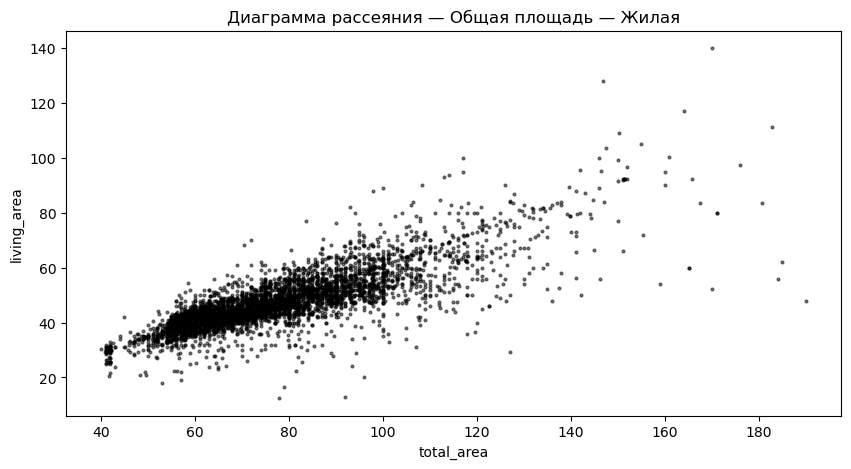

In [36]:
data[data['rooms'] == 3].query('total_area < 201 and last_price < 25_000_000').plot(kind='scatter',
        y='living_area' , x='total_area', alpha=0.5, subplots=True, figsize=(10,5), c = 'black', s = 4)
plt.title('Диаграмма рассеяния — Общая площадь — Жилая');

Если пропуски оставить или заполнить 0, то 'Диаграмма рассеяния — Общая площадь — Жилая' не меняется. Следовательно, заполнение 'living_area' корректное. А вот 'kitchen_area' заполнила исходя из предположения: 
    
    total_area*0.9 <= (living_area + kitchen_area).
Решение ниже.

Коридоры, сан.узлы, балконы — на них отводим условные 10% площади - новый столбец 'other_area'. Следовательно, заполним пропуски в столбце 'kitchen_area', вычитая из общей площади жилую и 10% оставшейся площади.

In [37]:
#создание нового столбца, содержащий 10% площади под коридоры, сан.узлы, балконы
data['other_area'] = (data['total_area'] - data['living_area'])*0.1
data['other_area'].round(2)

0        5.70
1        2.18
2        2.17
3        6.21
4        6.80
         ... 
23694    6.05
23695    2.10
23696    2.70
23697    3.27
23698    2.00
Name: other_area, Length: 23564, dtype: float64

In [38]:
#заполнение пропусков в 'kitchen_area'
data['kitchen_area'].fillna(data['total_area'] - data['living_area'] - data['other_area'], inplace=True) 
data['kitchen_area'].round(2)

0        25.00
1        11.00
2         8.30
3        55.90
4        41.00
         ...  
23694    13.83
23695     8.50
23696    24.30
23697    23.30
23698     9.00
Name: kitchen_area, Length: 23564, dtype: float64

In [39]:
data['kitchen_area'].isna().sum() 

0

In [40]:
data['ceiling_height'].isna().sum()

9083

Скорее всего пользователь забыл заполнить данный параметр или предположил, что это маловажный параметр и не стал заполнять. 
Заполним пропуски в 'ceiling_height' медианным значением высоты потолков в зависимости от расстояния до центра, т.к. в современных районах Питера высота потолков будет ожидаема ниже, чем в исторических.

In [41]:
#медианное значение высоты потолков в зависимости от расстояния до центра 
ceiling_height_median = data.groupby(['city_centers_nearest'])['ceiling_height'].transform('median') 
data['ceiling_height'] = data['ceiling_height'].fillna(ceiling_height_median) 

In [42]:
data['ceiling_height'].isna().sum()

4705

Пропуски в Питере заполнили — у питерских квартир почти нет пропусков в колонке 'city_centers_nearest', а остальные пропуски уже можно заполнить по медианному значения населенного пункта, т.к. основные различия в высоте потолков наблюдаются у питерских квартир.

In [43]:
#медианное значение высоты потолков в зависимости от населенного пункта и этажности дома
ceiling_height_median = data.groupby(['locality_name', 'floors_total'])['ceiling_height'].transform('median') 
ceiling_height_median

0        2.700
1        2.600
2        2.615
3        2.600
4        2.600
         ...  
23694    2.615
23695    2.500
23696      NaN
23697    2.700
23698    2.500
Name: ceiling_height, Length: 23564, dtype: float64

In [44]:
#заполнение пропусков в датафрйме в столбце 'ceiling_height' медианным значением высоты потолков 
#в зависимости от населенного пункта и этажности дома
data['ceiling_height'] = data['ceiling_height'].fillna(ceiling_height_median) 
data['ceiling_height'].round(2)

0        2.70
1        2.60
2        2.62
3        3.00
4        3.03
         ... 
23694    3.70
23695    2.50
23696     NaN
23697    3.00
23698    2.50
Name: ceiling_height, Length: 23564, dtype: float64

In [45]:
data['ceiling_height'].isna().sum() 

321

Остальные пропуски заполнили медианным значение высоты потолков в зависимости от категории местности:

In [46]:
for row in data['name'].unique():
    data.loc[(data['name'] == row) & (data['ceiling_height'].isna()), 'ceiling_height'] = \
    data.loc[(data['name'] == row), 'ceiling_height'].median()
data['ceiling_height']

0        2.700
1        2.600
2        2.615
3        3.000
4        3.030
         ...  
23694    3.700
23695    2.500
23696    2.575
23697    3.000
23698    2.500
Name: ceiling_height, Length: 23564, dtype: float64

In [47]:
data['ceiling_height'].isna().sum() 

0

In [48]:
data['city_centers_nearest'].isna().sum()

5501

In [49]:
city_centers_nearest_median = data.groupby(['locality_name'])['city_centers_nearest'].transform('median')
data['city_centers_nearest'] = data['city_centers_nearest'].fillna(city_centers_nearest_median)

In [50]:
data['city_centers_nearest'].isna().sum()

5432

In [51]:
data['airports_nearest'].isna().sum()

5524

In [52]:
airports_nearest_median = data.groupby(['city_centers_nearest', 'locality_name'])['airports_nearest'].transform('median')
data['airports_nearest'] = data['airports_nearest'].fillna(airports_nearest_median)

In [53]:
data['airports_nearest'].isna().sum()

5445

In [54]:
data['airports_nearest'] = (data['airports_nearest'] / 1000).round(2)
data['airports_nearest'].value_counts()

airports_nearest
36.72    83
37.43    63
37.41    53
39.14    51
21.93    39
         ..
40.73     1
40.77     1
28.72     1
9.85      1
13.69     1
Name: count, Length: 3838, dtype: int64

Перевела значения 'airports_nearest' в км.

In [55]:
data['parks_around3000'].isna().sum()

5500

In [56]:
parks_around3000_median = data.groupby(['city_centers_nearest', 'locality_name'])['parks_around3000'].transform('median')
data['parks_around3000'] = data['parks_around3000'].fillna(parks_around3000_median)

In [57]:
data['parks_around3000'].isna().sum()

5437

In [58]:
data['ponds_around3000'].isna().sum()

5500

In [59]:
ponds_around3000_median = data.groupby(['city_centers_nearest', 'locality_name'])['ponds_around3000'].transform('median')
data['ponds_around3000'] = data['ponds_around3000'].fillna(ponds_around3000_median)

In [60]:
data['ponds_around3000'].isna().sum()

5437

In [61]:
data['parks_nearest'].isna().sum()

15534

In [62]:
parks_nearest_median = data.groupby(['city_centers_nearest', 'locality_name'])['parks_nearest'].transform('median')
data['parks_nearest'] = data['parks_nearest'].fillna(parks_nearest_median)

In [63]:
data['parks_nearest'].isna().sum()

13939

In [64]:
data['ponds_nearest'].isna().sum()

14528

In [65]:
ponds_nearest_median = data.groupby(['city_centers_nearest', 'locality_name'])['ponds_nearest'].transform('median')
data['ponds_nearest'] = data['ponds_nearest'].fillna(ponds_nearest_median)

In [66]:
data['ponds_nearest'].isna().sum()

13009

days_exposition - незаполненные пропуски скорее всего связано с тем, что объявление еще не закрыто или не было закрыто вовремя. Оставила значения неизменным. 

In [67]:
data.info()
print(data.isna().sum()) #проверка на количество пропущенных значений

<class 'pandas.core.frame.DataFrame'>
Index: 23564 entries, 0 to 23698
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   total_images          23564 non-null  int64         
 1   last_price            23564 non-null  int32         
 2   total_area            23564 non-null  float64       
 3   first_day_exposition  23564 non-null  datetime64[ns]
 4   rooms                 23564 non-null  int64         
 5   ceiling_height        23564 non-null  float64       
 6   floors_total          23564 non-null  int32         
 7   living_area           23564 non-null  float64       
 8   floor                 23564 non-null  int64         
 9   is_apartment          23564 non-null  bool          
 10  studio                23564 non-null  bool          
 11  open_plan             23564 non-null  bool          
 12  kitchen_area          23564 non-null  float64       
 13  balcony              

In [68]:
all_new = (data.isnull().sum ()/ len(data))* 100 # процент пропусков в столбцах
all_new

total_images             0.000000
last_price               0.000000
total_area               0.000000
first_day_exposition     0.000000
rooms                    0.000000
ceiling_height           0.000000
floors_total             0.000000
living_area              0.000000
floor                    0.000000
is_apartment             0.000000
studio                   0.000000
open_plan                0.000000
kitchen_area             0.000000
balcony                  0.000000
locality_name            0.000000
airports_nearest        23.107282
city_centers_nearest    23.052113
parks_around3000        23.073332
parks_nearest           59.153794
ponds_around3000        23.073332
ponds_nearest           55.207096
days_exposition         13.456968
name                     0.000000
other_area               0.000000
dtype: float64

In [69]:
#посчитаем кол-во оставшихся пропусков во всем датасете  
missing_values = data.isnull().sum() #кол-во пропущенных значений в столбцах
total_missing = missing_values.sum() #кол-во пропущенных значений во всем датасете 
total_cells = data.size #кол-во ячеек во всем датасете 
missing_ratio = total_missing / total_cells 
missing_ratio 

0.09171829910032253

***Вывод:*** 
Причины пропусков:
1. Пользователь не стал указывать данные
2. Сбой системы при выгрузки данных.
3. Некорректная работа геосервисов - отсутствие данных по некоторым населенным пунктам или же пропущенные значения превышают значения радиуса поиска.
Наблюдается одинаковая тенденция по числу оставшихся пропусков в столбцах 'airports_nearest', 'city_centers_nearest', 'parks_around3000', 'ponds_around3000'. Предположение - некорректная работа геосервисов, возможно пропущенные значения находятся за пределами радиуса поиска.
Столбец days_exposition - скорее всего пропуски это еще активные объявления; пропуски пока оставила, рассмотрю их отдельно.
Число пропусков во всем датасете сократили примерно с 19% до 9%. 

## Шаг 3. Добавить в таблицу новые столбцы

In [70]:
data['price_one'] = data['last_price'] / data['total_area'] #добавлен столбец 'price_one', содержищий цену за 1 кв.м.
data['price_one'] = data['price_one'].round(2) #столбец перевела в целочисленный тип данных.
data['price_one']

0        120370.37
1         82920.79
2         92785.71
3        408176.10
4        100000.00
           ...    
23694     72490.85
23695     52542.37
23696     44091.71
23697    149511.40
23698     41795.67
Name: price_one, Length: 23564, dtype: float64

In [71]:
data['weekday'] = data['first_day_exposition'].dt.weekday #добавлен столбец 'weekday'
data['month'] = data['first_day_exposition'].dt.month #добавлен столбец 'month'
data['year'] = data['first_day_exposition'].dt.year #добавлен столбец 'year'

In [72]:
data['floor'].value_counts()

floor
2     3350
3     3061
1     2909
4     2793
5     2612
6     1293
7     1211
8     1075
9     1045
10     684
11     520
12     519
13     376
15     340
14     333
16     315
17     226
18     175
19     144
21     119
22     111
20     108
23      98
24      61
25      46
26      24
27      10
28       1
30       1
29       1
32       1
33       1
31       1
Name: count, dtype: int64

In [73]:
def floor_type (row): # создание функции с условиями категоризации
    if row['floor'] == 1:
        return 'первый'
    elif row['floor'] == row['floors_total']:
         return 'последний'
    elif 1 < row['floor'] < row['floors_total']:
         return 'средний'    
    else:
        return 'другой'
data['floor_type'] = data.apply(floor_type, axis=1) #добавлен столбец 'floor_type' c категоризацией этажей

In [74]:
#добавлен столбец 'city_centers_km' - расстояние до центра в км.
data['city_centers_km'] = (data['city_centers_nearest'] / 1000).round(0)
data['city_centers_km'].value_counts()

city_centers_km
12.0    1658
15.0    1561
13.0    1451
14.0    1276
16.0    1265
        ... 
62.0       1
59.0       1
45.0       1
61.0       1
63.0       1
Name: count, Length: 61, dtype: int64

***Вывод:***
добавлены новые столбцы для последующего исследовательского анализа.

## Шаг 4. Провести исследовательский анализ данных

###  Изучение перечисленных ниже параметров объектов и построение отдельных гистограмм для каждого из этих параметров:
- общая площадь;
- жилая площадь;
- площадь кухни;
- цена объекта;
- количество комнат;
- высота потолков;
- тип этажа квартиры («первый», «последний», «другой»);
- общее количество этажей в доме;
- расстояние до центра города в метрах;
- расстояние до ближайшего парка

Проверка аномалий: обращаем внимание на минимальные и максимальные значения в выборке и учитываем наличие пропусков при фильтрации данных

In [75]:
(
    data[['rooms', 'total_area', 'ceiling_height', 'days_exposition', 'last_price', 'living_area',  'kitchen_area',
          'floor', 'floors_total']]
    .apply (['count', 'min', 'max', 'median'])   
    .style.format("{:,.2f}")
)

,rooms,total_area,ceiling_height,days_exposition,last_price,living_area,kitchen_area,floor,floors_total
count,"23,564.00","23,564.00","23,564.00","20,393.00","23,564.00","23,564.00","23,564.00","23,564.00","23,564.00"
min,0.00,12.00,1.00,1.00,"12,190.00",2.00,0.00,1.00,1.00
max,19.00,900.00,100.00,"1,580.00","763,000,000.00",427.55,231.86,33.00,60.00
median,2.00,52.00,2.65,95.00,"4,646,000.00",30.00,9.70,4.00,9.00


In [76]:
data['total_area'].describe() #описательная статистика общей площади

count    23564.000000
mean        60.316833
std         35.645953
min         12.000000
25%         40.000000
50%         52.000000
75%         69.700000
max        900.000000
Name: total_area, dtype: float64

Медиана от среднего отличается незначительно, т.е. есть выбросы, но они не сильно влияют на данные.

Выбросы начинаются с 100 кв.м., следовательно, отметила этот порог на гистограмме.

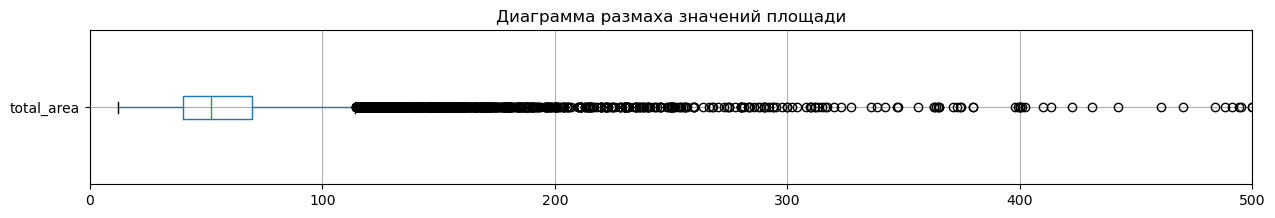

In [77]:
fig, ax = plt.subplots(figsize = (15,2))
ax = data[['total_area']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха значений площади')
ax.set_xlim(0, 500);

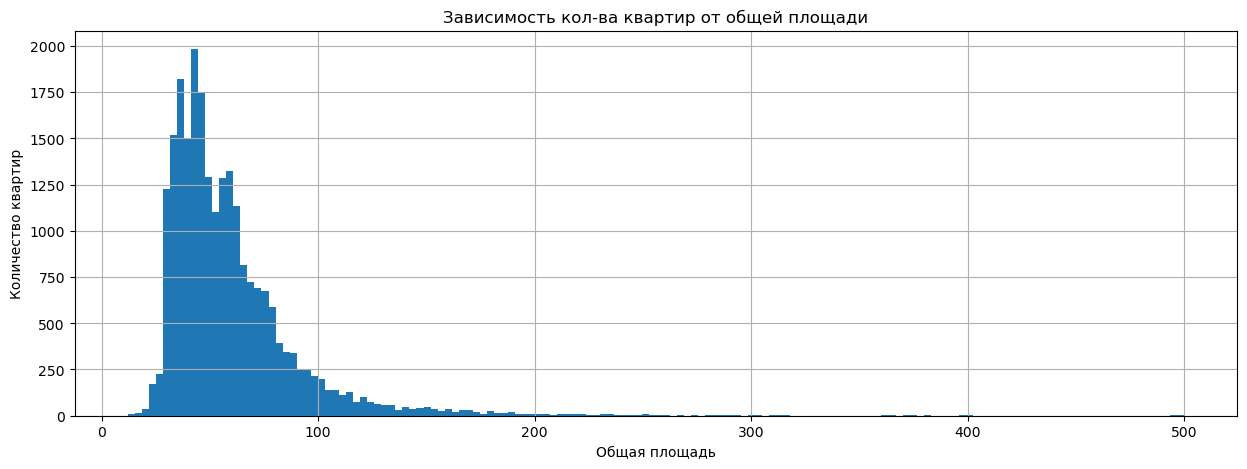

In [78]:
data['total_area'].plot(kind='hist', bins=150, grid=True, figsize = (15, 5), range=(12,500)) 
plt.ylabel('Количество квартир')
plt.xlabel('Общая площадь')
plt.title('Зависимость кол-ва квартир от общей площади');

Больше всего квартир с общей площадью 30-100 кв.м. Пики на 31-50 и 60 кв.м.

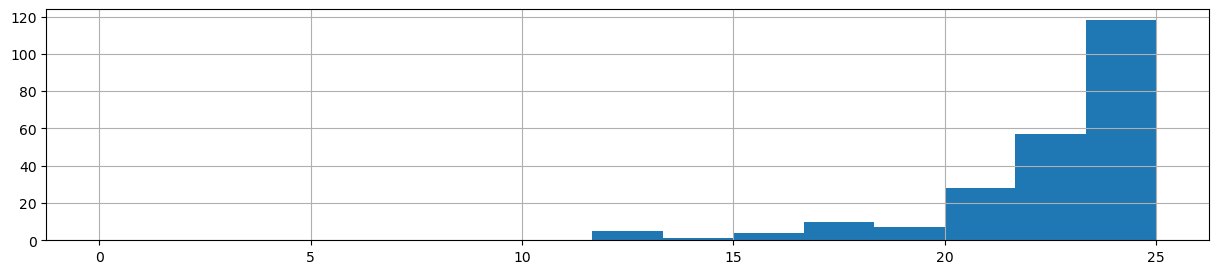

In [79]:
data['total_area'].hist(bins = 15, figsize = (15,3), range = (0,25));

Возрастает кол-во квартир на значении 20 кв.м - начальное значение среза.

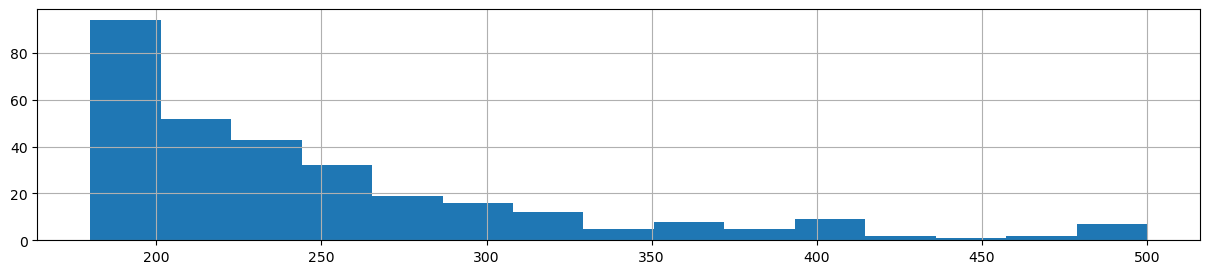

In [80]:
data['total_area'].hist(bins = 15, figsize = (15,3), range = (180,500));

Конечное значение 260 кв.м.

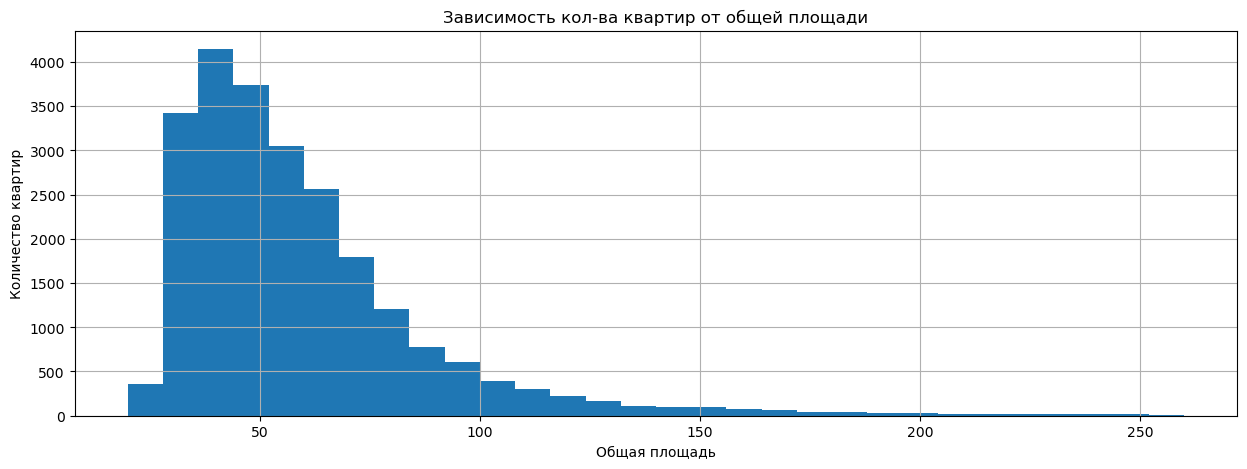

In [81]:
#срез данных без аномалий, сохраняем их в новый датафрейм good_data
good_data = data.query('total_area >= 20 and total_area <= 260')
good_data['total_area'].plot(kind='hist', bins=30, grid=True, figsize = (15, 5)) 
plt.ylabel('Количество квартир')
plt.xlabel('Общая площадь')
plt.title('Зависимость кол-ва квартир от общей площади');

In [82]:
print(len(good_data) / len(data))  

0.994865048378883


Срез убрал примерно 1% значений.

In [83]:
data['living_area'].describe() #описательная статистика жилой площади

count    23564.000000
mean        34.630353
std         22.745322
min          2.000000
25%         18.700000
50%         30.000000
75%         42.300000
max        427.546729
Name: living_area, dtype: float64

Медиана от среднего отличается незначительно, т.е. есть выбросы, но они не сильно влияют на данные.

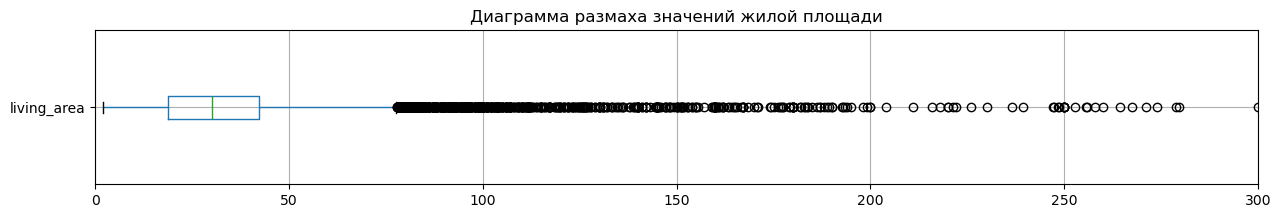

In [84]:
fig, ax = plt.subplots(figsize = (15,2))
ax = data[['living_area']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха значений жилой площади')
ax.set_xlim(0, 300);

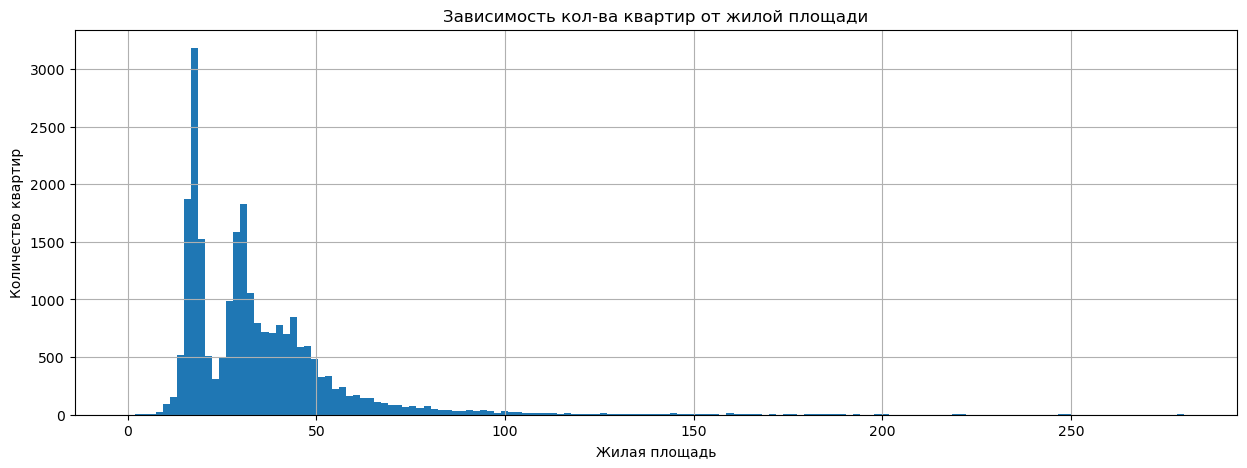

In [85]:
data['living_area'].plot(kind='hist', bins=150, grid=True, figsize = (15, 5), range=(0,280))
plt.ylabel('Количество квартир')
plt.xlabel('Жилая площадь')
plt.title('Зависимость кол-ва квартир от жилой площади');

Есть 2 основных пика - больше всего квартир с жилой площадью 14-20 кв.м. и 26-44 кв.м. Всплески на 18, 30, 44 кв.м.

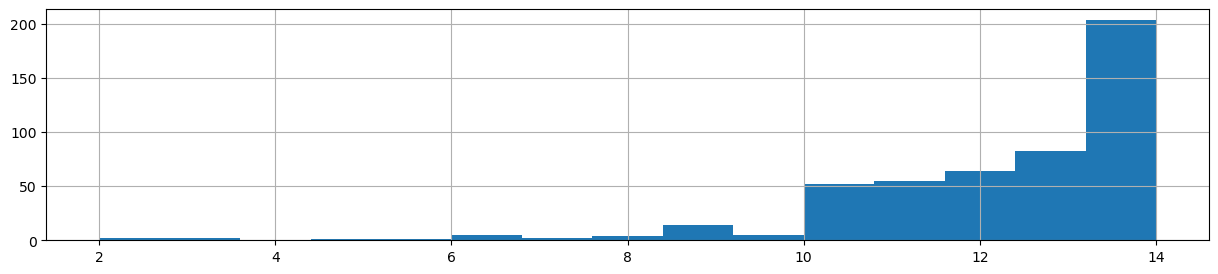

In [86]:
data['living_area'].hist(bins = 15, figsize = (15,3), range = (2,14));

Возрастает кол-во квартир на значении 10 кв.м - начальное значение среза.

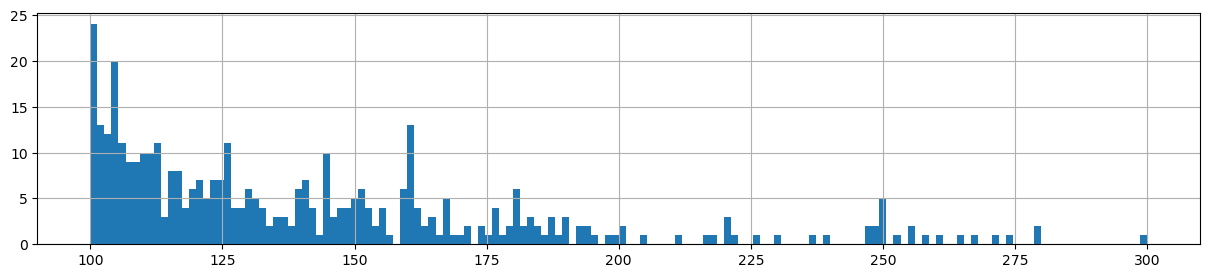

In [87]:
data['living_area'].hist(bins = 150, figsize = (15,3), range = (100,300));

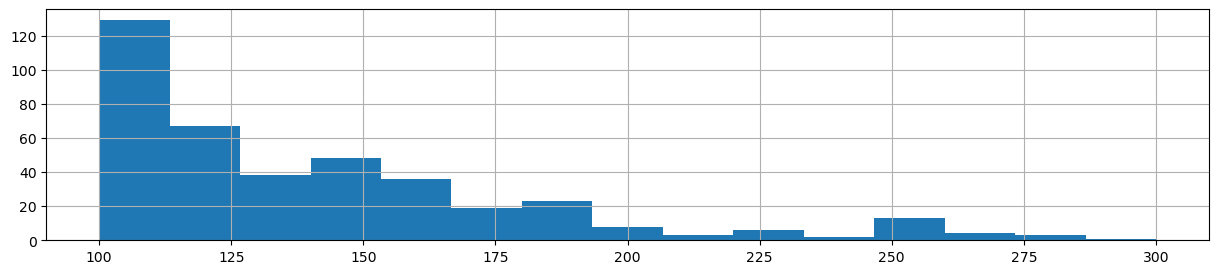

In [88]:
data['living_area'].hist(bins = 15, figsize = (15,3), range = (100,300));

Наблюдается спад на 250 кв.м - конечное значение среза.

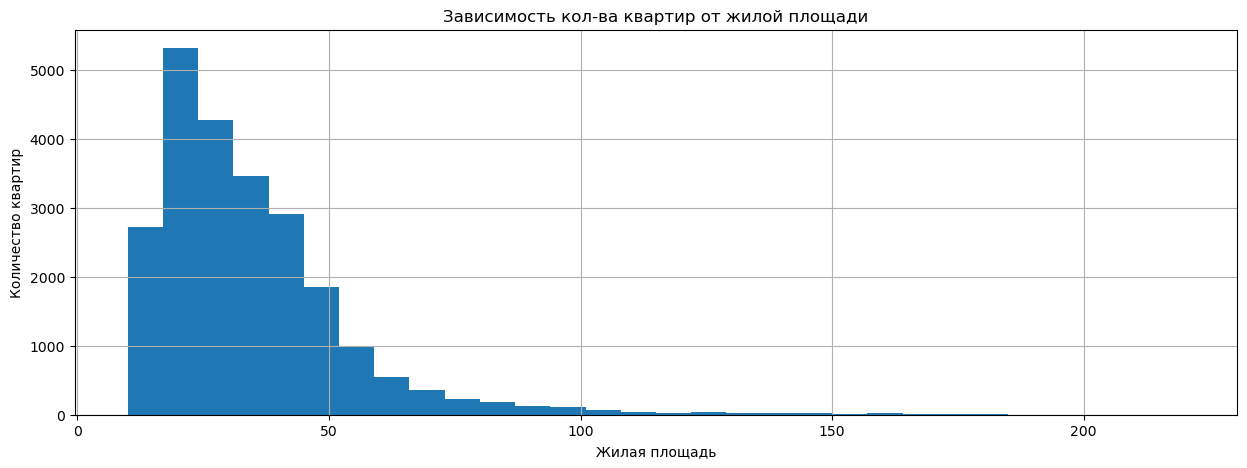

In [89]:
#срез данных без аномалий, сохраняем их в новый датафрейм good_data
good_data = good_data.query('living_area >= 10 and living_area <= 250')
good_data['living_area'].plot(kind='hist', bins=30, grid=True, figsize = (15, 5)) 
plt.ylabel('Количество квартир')
plt.xlabel('Жилая площадь')
plt.title('Зависимость кол-ва квартир от жилой площади');

In [90]:
print(len(good_data) / len(data)) 

0.99371923272789


In [91]:
data['kitchen_area'].describe() #описательная статистика площади кухни

count    23564.000000
mean        11.533559
std          7.791511
min          0.000000
25%          7.200000
50%          9.700000
75%         13.000000
max        231.857086
Name: kitchen_area, dtype: float64

Медиана от среднего отличается незначительно, т.е. есть выбросы, но они не сильно влияют на данные.

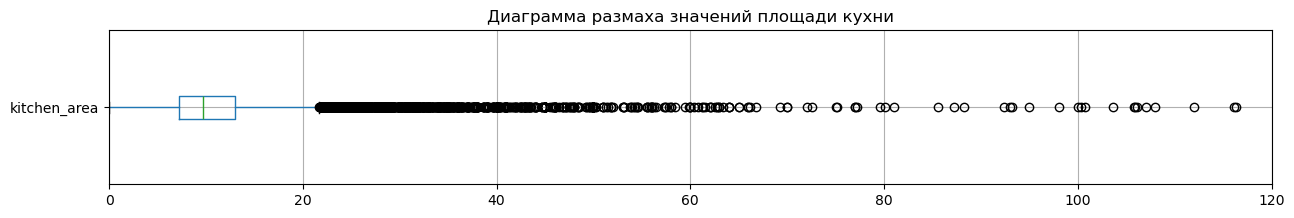

In [92]:
fig, ax = plt.subplots(figsize = (15,2))
ax = data[['kitchen_area']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха значений площади кухни')
ax.set_xlim(0, 120);

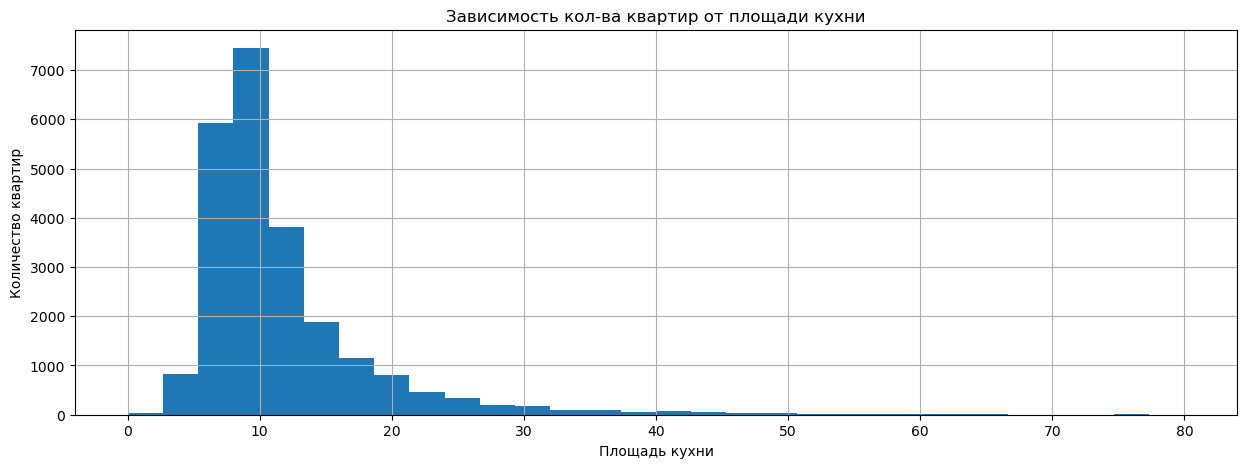

In [93]:
data['kitchen_area'].plot(kind='hist', bins=30, grid=True, figsize = (15, 5), range=(0, 80)) 
plt.ylabel('Количество квартир')
plt.xlabel('Площадь кухни')
plt.title('Зависимость кол-ва квартир от площади кухни');

Больше всего квартир с площадью кухни от 5 до 18 кв.м. - всплески на 6, 7, 8, 9 и 10 кв.м.

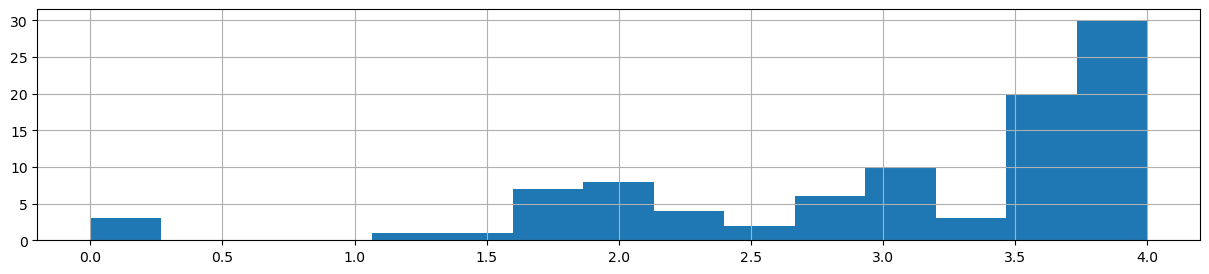

In [94]:
data['kitchen_area'].hist(bins = 15, figsize = (15,3), range = (0,4));

Возрастает кол-во квартир на значении 3.5 кв.м - начальное значения среза.

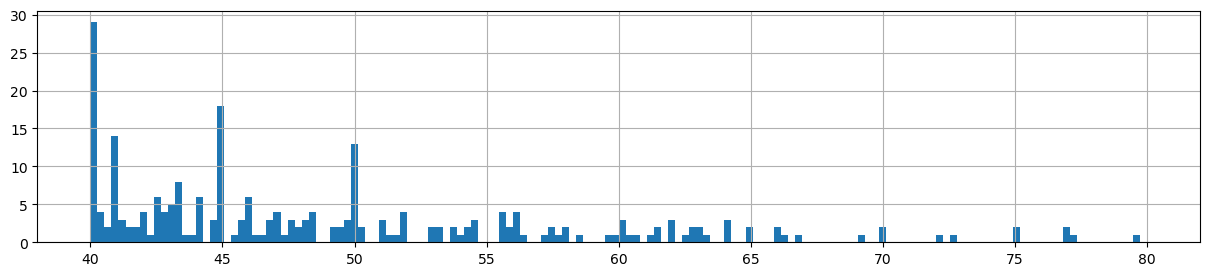

In [95]:
data['kitchen_area'].hist(bins = 150, figsize = (15,3), range = (40,80));

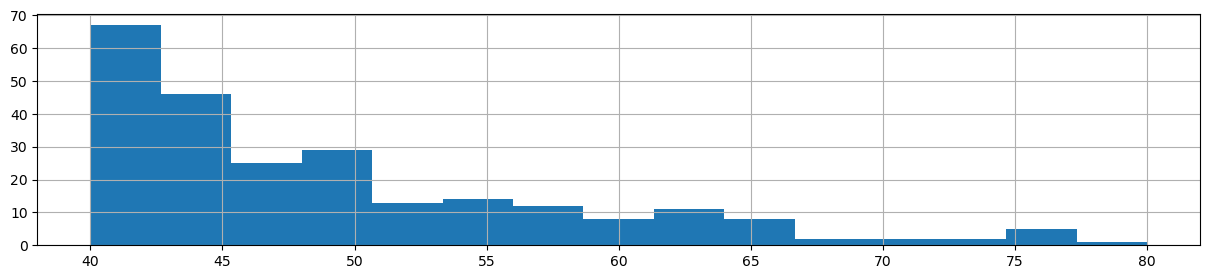

In [96]:
data['kitchen_area'].hist(bins = 15, figsize = (15,3), range = (40,80));

Наблюдается спад на 50 кв.м - конечное значение среза.

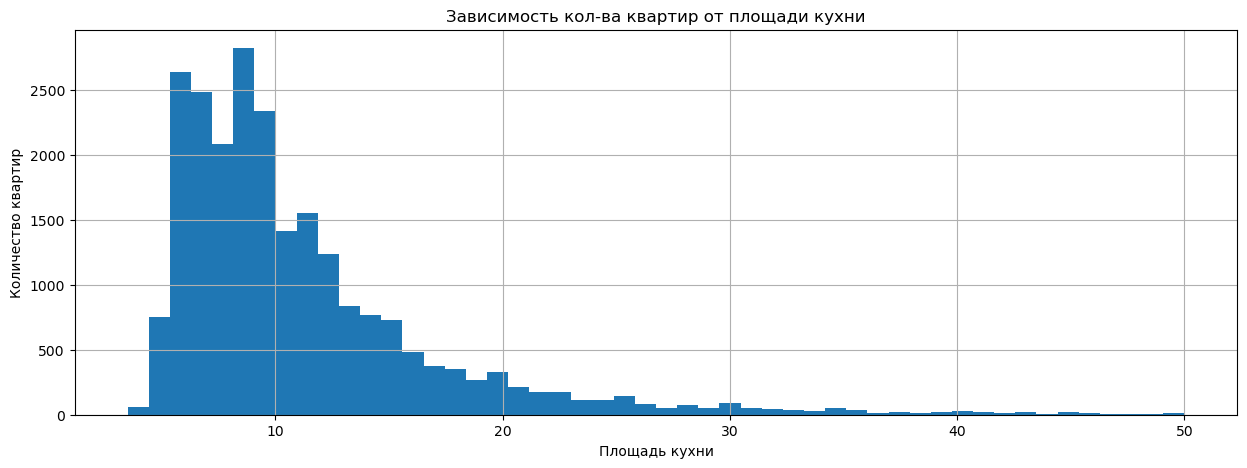

In [97]:
#срез данных без аномалий, сохраняем их в новый датафрейм good_data
good_data = good_data.query('kitchen_area >= 3.5 and kitchen_area <= 50')
good_data['kitchen_area'].plot(kind='hist', bins=50, grid=True, figsize = (15, 5)) 
plt.ylabel('Количество квартир')
plt.xlabel('Площадь кухни')
plt.title('Зависимость кол-ва квартир от площади кухни');

In [98]:
print(len(good_data) / len(data)) 

0.9888813444236971


In [99]:
data['last_price'].describe() #описательная статистика цены

count    2.356400e+04
mean     6.540001e+06
std      1.091116e+07
min      1.219000e+04
25%      3.400000e+06
50%      4.646000e+06
75%      6.790000e+06
max      7.630000e+08
Name: last_price, dtype: float64

Медиана от среднего отличается, т.е. есть выбросы. 

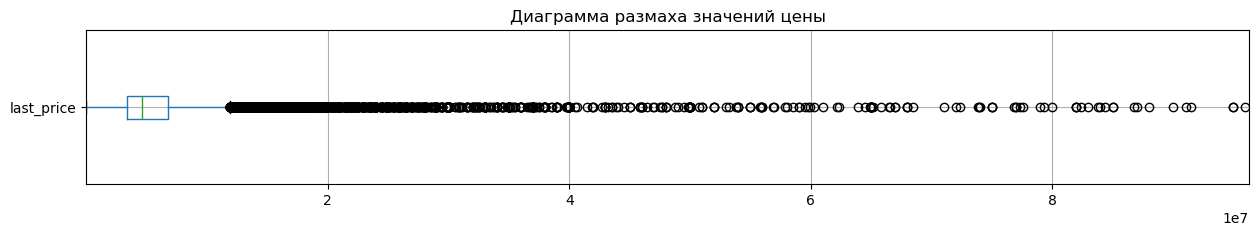

In [100]:
fig, ax = plt.subplots(figsize = (15,2))
ax = data[['last_price']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха значений цены')
ax.set_xlim(1.219000e+04,9.630000e+07);

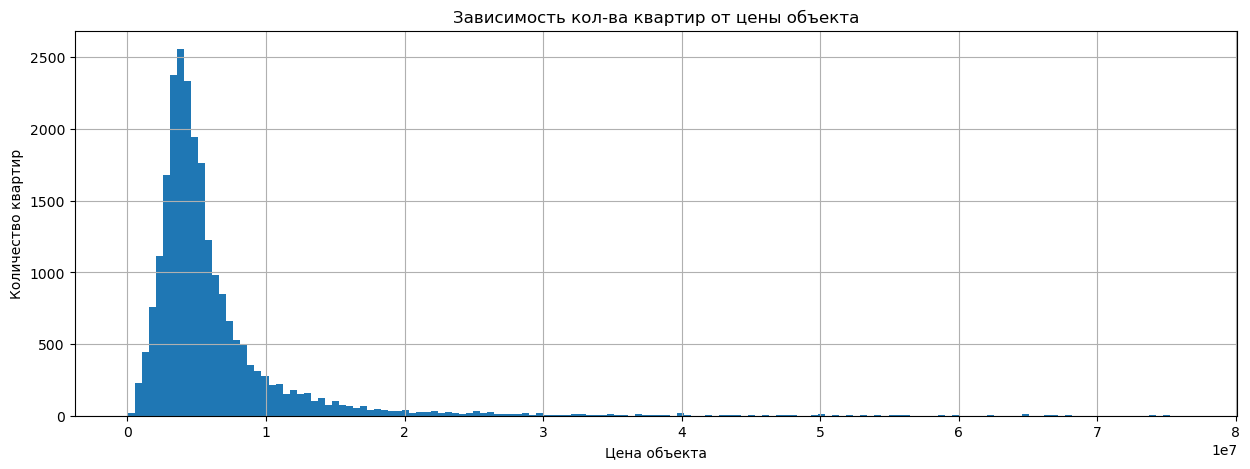

In [101]:
data['last_price'].plot(kind='hist', bins=150, grid=True, figsize = (15, 5), range=(1.219000e+04,7.630000e+07)) 
plt.ylabel('Количество квартир')
plt.xlabel('Цена объекта')
plt.title('Зависимость кол-ва квартир от цены объекта');

В основной массе цена квартиры в пределах 2-8 млн.руб. Всплеск на 3-4 млн.

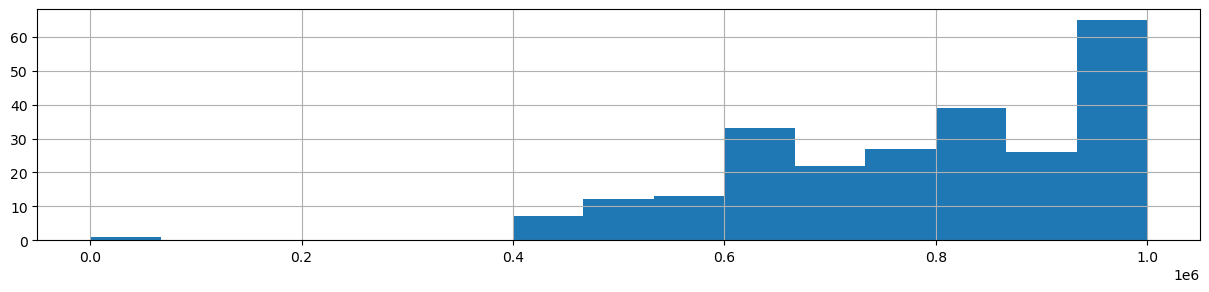

In [102]:
data['last_price'].hist(bins = 15, figsize = (15,3), range = (0, 1000000));

Возрастает кол-во квартир на значении 400 тыс.рублей - начальное значения среза.

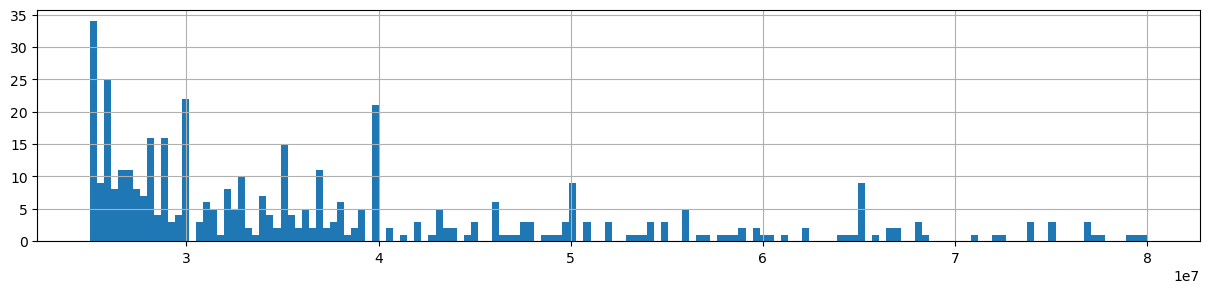

In [103]:
data['last_price'].hist(bins = 150, figsize = (15,3), range = (25000000, 80000000));

Конечное значение - 65 млн.руб.

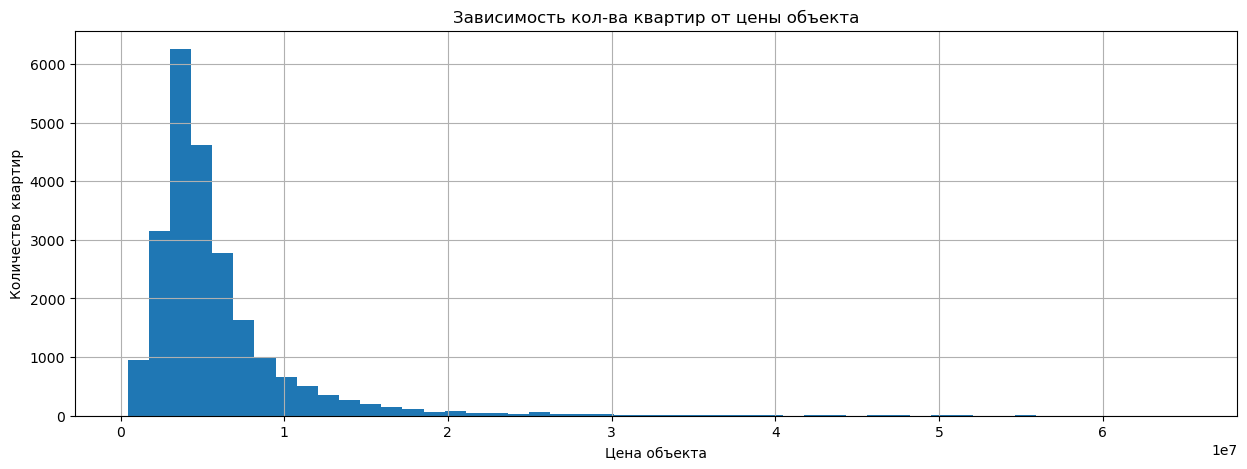

In [104]:
#срез данных без аномалий, сохраняем их в новый датафрейм good_data
good_data = good_data.query('last_price >= 400000 and last_price <= 65000000')
good_data['last_price'].plot(kind='hist', bins=50, grid=True, figsize = (15, 5)) 
plt.ylabel('Количество квартир')
plt.xlabel('Цена объекта')
plt.title('Зависимость кол-ва квартир от цены объекта');

In [105]:
print(len(good_data) / len(data)) 

0.9871414021388559


In [106]:
data['rooms'].describe() #описательная статистика числа комнат

count    23564.000000
mean         2.070446
std          1.078135
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         19.000000
Name: rooms, dtype: float64

Медиана от среднего не отличаются, данные хорошие.

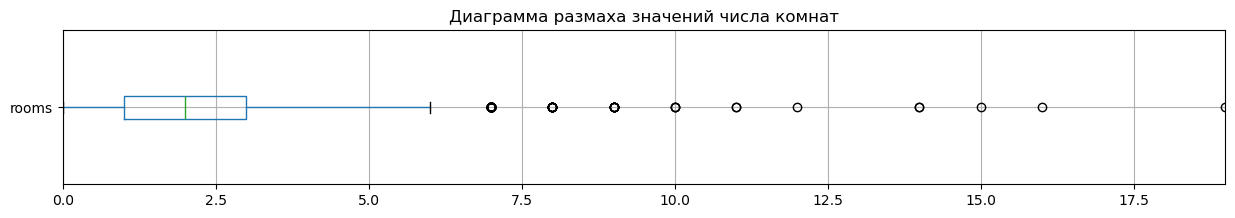

In [107]:
fig, ax = plt.subplots(figsize = (15,2))
ax = data[['rooms']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха значений числа комнат')
ax.set_xlim(0, 19);

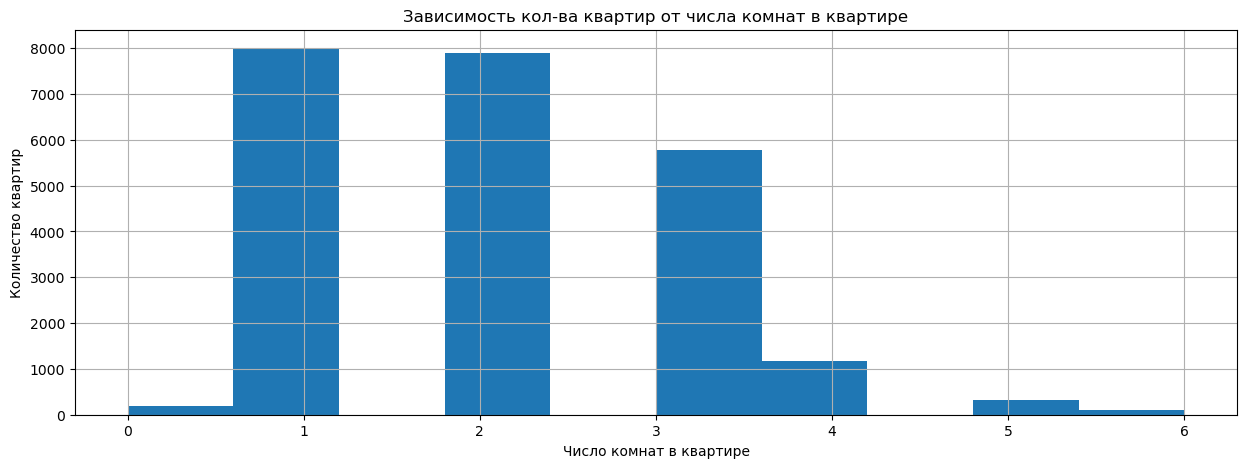

In [108]:
data['rooms'].plot(kind='hist', bins=10, grid=True, figsize = (15, 5), range=(0,6))
plt.ylabel('Количество квартир')
plt.xlabel('Число комнат в квартире')
plt.title('Зависимость кол-ва квартир от числа комнат в квартире');

Практически одинаково большое кол-во квартир с 1 и 2 комнатами. С увеличением числа комнат, кол-во квартир резко снижается.

In [109]:
data['rooms'].value_counts().to_frame()

,count
rooms,
1,8004
2,7897
3,5779
4,1172
5,325
0,194
6,104
7,58
8,12


рассматриваем срез квартир с кол-ом комнат до 7.

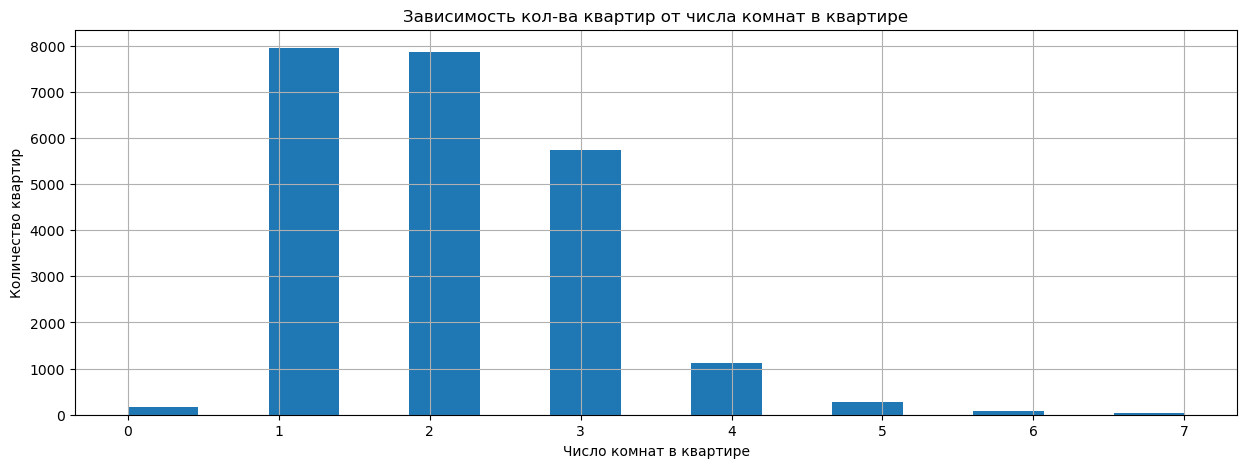

In [110]:
#срез данных без аномалий, сохраняем их в новый датафрейм good_data
good_data = good_data.query('rooms >= 0 and rooms <= 7')
good_data['rooms'].plot(kind='hist', bins=15, grid=True, figsize = (15, 5)) 
plt.ylabel('Количество квартир')
plt.xlabel('Число комнат в квартире')
plt.title('Зависимость кол-ва квартир от числа комнат в квартире');

In [111]:
print(len(good_data) / len(data)) 

0.9866321507384145


In [112]:
data['ceiling_height'].unique() #список уникальных значений в столбце 'ceiling_height'

array([  2.7   ,   2.6   ,   2.615 ,   3.    ,   3.03  ,   2.65  ,
         2.6   ,   2.75  ,   2.5   ,   2.67  ,   2.55  ,   2.56  ,
         3.05  ,   2.54  ,   2.9   ,   2.8   ,   2.57  ,   2.76  ,
         3.2   ,   2.725 ,   2.575 ,   4.    ,   2.64  ,   2.61  ,
         2.57  ,   2.84  ,   3.11  ,   3.25  ,   3.45  ,   3.28  ,
         2.77  ,   2.85  ,   2.525 ,   4.15  ,   3.5   ,   2.62  ,
         3.3   ,   2.71  ,   2.47  ,   2.73  ,   3.1   ,   3.58  ,
         2.625 ,   2.675 ,   2.34  ,   2.775 ,   3.4   ,   2.52  ,
         3.06  ,   2.72  ,   2.51  ,   2.65  ,   2.78  ,  27.    ,
        25.    ,   2.58  ,   3.7   ,   3.15  ,   5.2   ,   3.015 ,
         3.34  ,   2.87  ,   2.66  ,   2.59  ,   2.    ,   2.45  ,
         3.6   ,   2.53  ,   5.    ,   2.92  ,   2.79  ,   3.13  ,
         2.875 ,   2.735 ,   3.8   ,   2.585 ,   3.55  ,   2.725 ,
         3.475 ,   3.16  ,   2.7375,   3.62  ,   3.12  ,   2.74  ,
         2.96  ,   2.46  ,   2.69  ,   2.685 ,   5.3   ,   2.9

Есть аномальные значений. Перенесем запятую на одно деление.

In [113]:
#выбор строк со значением больше 10 и деление на 10
data.loc[data['ceiling_height'] >= 10.0, 'ceiling_height'] = data['ceiling_height']/10 
data['ceiling_height'].unique()

array([ 2.7   ,  2.6   ,  2.615 ,  3.    ,  3.03  ,  2.65  ,  2.6   ,
        2.75  ,  2.5   ,  2.67  ,  2.55  ,  2.56  ,  3.05  ,  2.54  ,
        2.9   ,  2.8   ,  2.57  ,  2.76  ,  3.2   ,  2.725 ,  2.575 ,
        4.    ,  2.64  ,  2.61  ,  2.57  ,  2.84  ,  3.11  ,  3.25  ,
        3.45  ,  3.28  ,  2.77  ,  2.85  ,  2.525 ,  4.15  ,  3.5   ,
        2.62  ,  3.3   ,  2.71  ,  2.47  ,  2.73  ,  3.1   ,  3.58  ,
        2.625 ,  2.675 ,  2.34  ,  2.775 ,  3.4   ,  2.52  ,  3.06  ,
        2.72  ,  2.51  ,  2.65  ,  2.78  ,  2.58  ,  3.7   ,  3.15  ,
        5.2   ,  3.015 ,  3.34  ,  2.87  ,  2.66  ,  2.59  ,  2.    ,
        2.45  ,  3.6   ,  2.53  ,  5.    ,  2.92  ,  2.79  ,  3.13  ,
        2.875 ,  2.735 ,  3.8   ,  2.585 ,  3.55  ,  2.725 ,  3.475 ,
        3.16  ,  2.7375,  3.62  ,  3.12  ,  2.74  ,  2.96  ,  2.46  ,
        2.69  ,  2.685 ,  5.3   ,  2.95  ,  4.06  ,  2.94  ,  3.82  ,
        3.54  ,  3.53  ,  2.83  ,  3.325 ,  4.7   ,  2.545 ,  2.4   ,
        3.38  ,  3.0

In [114]:
data['ceiling_height'].describe()  #описательная статистика высоты потолков

count    23564.000000
mean         2.714544
std          0.268909
min          1.000000
25%          2.550000
50%          2.650000
75%          2.760000
max         10.000000
Name: ceiling_height, dtype: float64

Медиана от среднего не отличаются, данные хорошие.

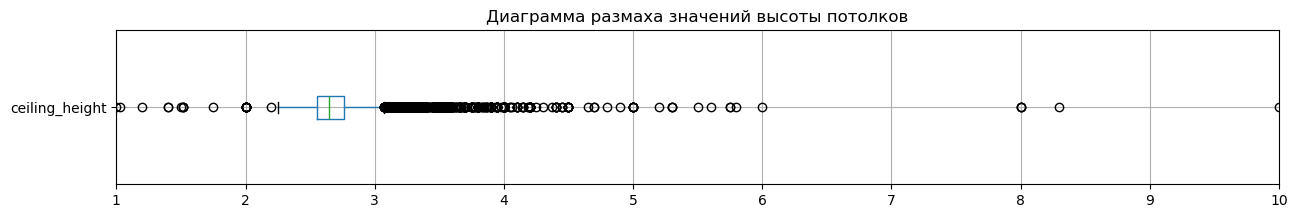

In [115]:
fig, ax = plt.subplots(figsize = (15,2))
ax = data[['ceiling_height']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха значений высоты потолков')
ax.set_xlim(1, 10);

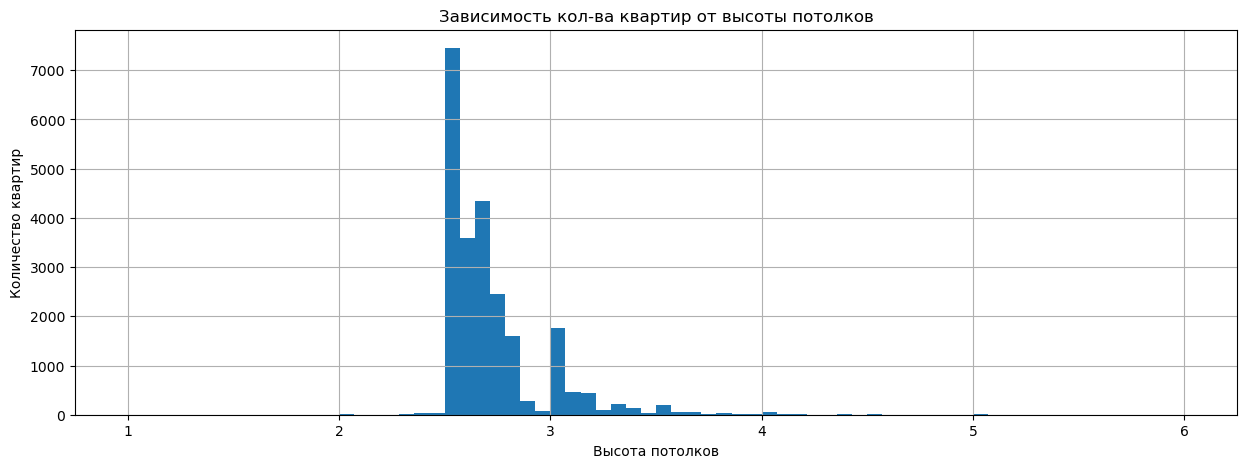

In [116]:
data['ceiling_height'].plot(kind='hist', bins=70, grid=True, figsize = (15, 5), range=(1, 6)) 
plt.ylabel('Количество квартир')
plt.xlabel('Высота потолков')
plt.title('Зависимость кол-ва квартир от высоты потолков');

Большинство квартир с высотой потолков 2.5 - 3 м. Всплески на 2.5 и 2.7 м.

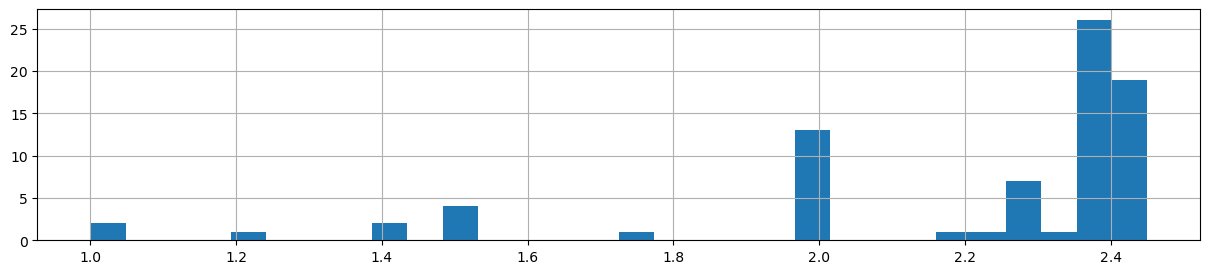

In [117]:
data['ceiling_height'].hist(bins = 30, figsize = (15,3), range = (1, 2.45));

Возрастает кол-во квартир на значении 2 м - начальное значение среза.

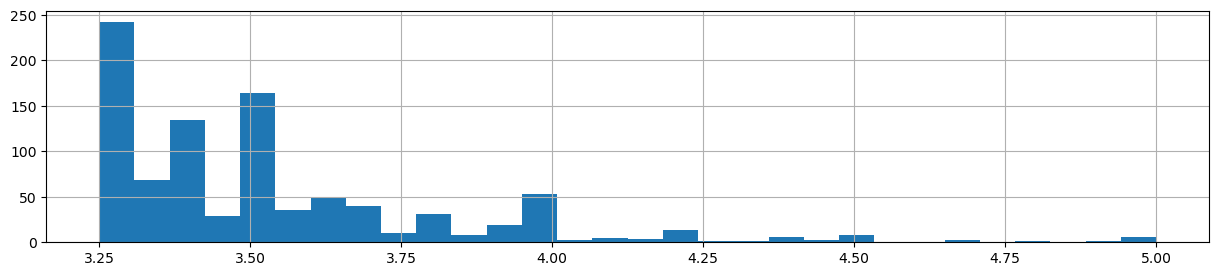

In [118]:
data['ceiling_height'].hist(bins =30, figsize = (15,3), range = (3.25, 5));

Конечное значение - 4 м.

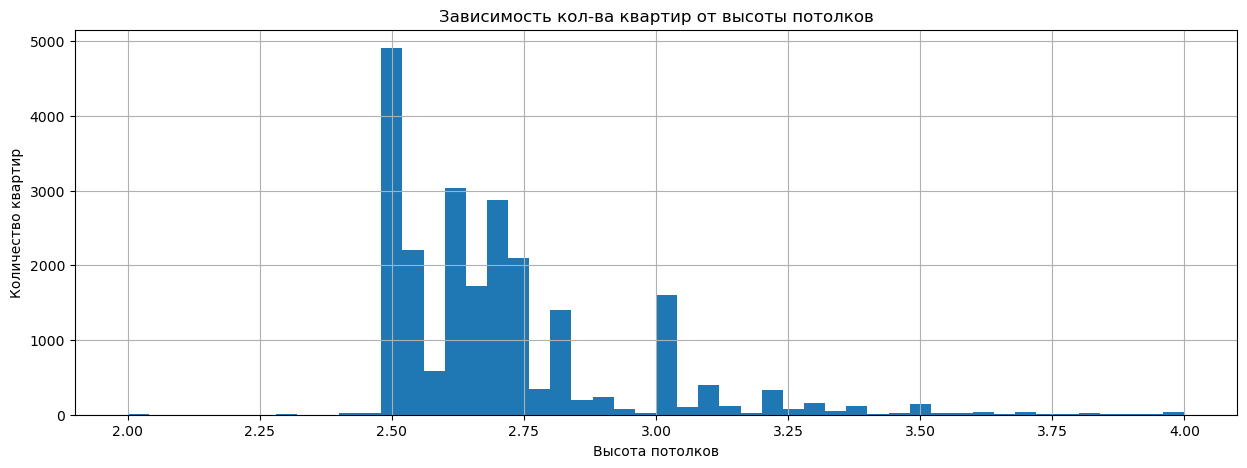

In [119]:
#срез данных без аномалий, сохраняем их в новый датафрейм good_data
good_data = good_data.query('ceiling_height >= 2 and ceiling_height <= 4')
good_data['ceiling_height'].plot(kind='hist', bins=50, grid=True, figsize = (15, 5)) 
plt.ylabel('Количество квартир')
plt.xlabel('Высота потолков')
plt.title('Зависимость кол-ва квартир от высоты потолков');

In [120]:
print(len(good_data) / len(data)) 

0.9828552028518078


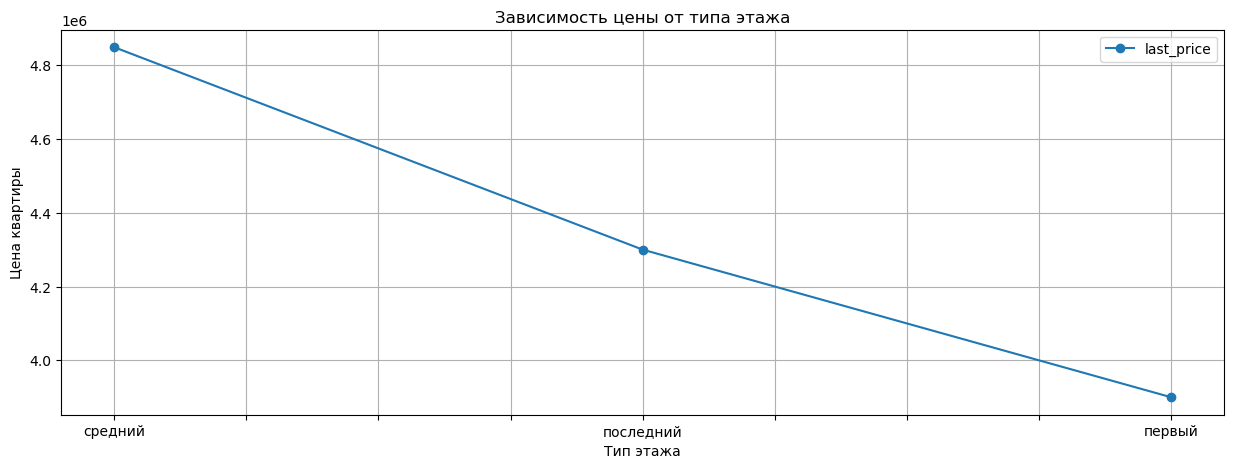

In [121]:
floor_type_price = data.pivot_table(index='floor_type', values='last_price', aggfunc='median').sort_values(by='last_price', ascending=False)
floor_type_price.plot(grid=True, style='o-', figsize=(15, 5), title='Зависимость цены от типа этажа', xlabel='Тип этажа',ylabel='Цена квартиры');

Прослеживается зависимость цены от типа этажа. Цены на квартиры на первых и последних этажах значительно ниже. 

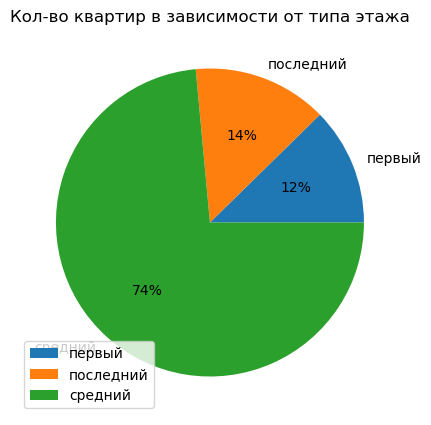

In [122]:
(
    data.groupby(['floor_type']).count()
.plot(kind='pie', y='last_price', autopct='%1.0f%%', figsize=(10,5), label='', title='Кол-во квартир в зависимости от типа этажа')
);

Кол-во квартир на первых и последних этажах составляют 26% от всего рынка предложений.

In [123]:
data['floors_total'].describe() #описательная статистика этажности домов

count    23564.000000
mean        10.676243
std          6.594721
min          1.000000
25%          5.000000
50%          9.000000
75%         16.000000
max         60.000000
Name: floors_total, dtype: float64

Медиана от среднего отличается незначительно, т.е. есть выбросы, но они не сильно влияют на данные.

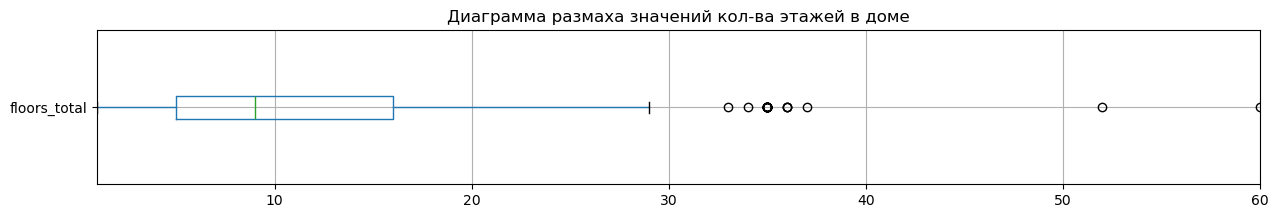

In [124]:
fig, ax = plt.subplots(figsize = (15,2))
ax = data[['floors_total']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха значений кол-ва этажей в доме')
ax.set_xlim(1, 60);

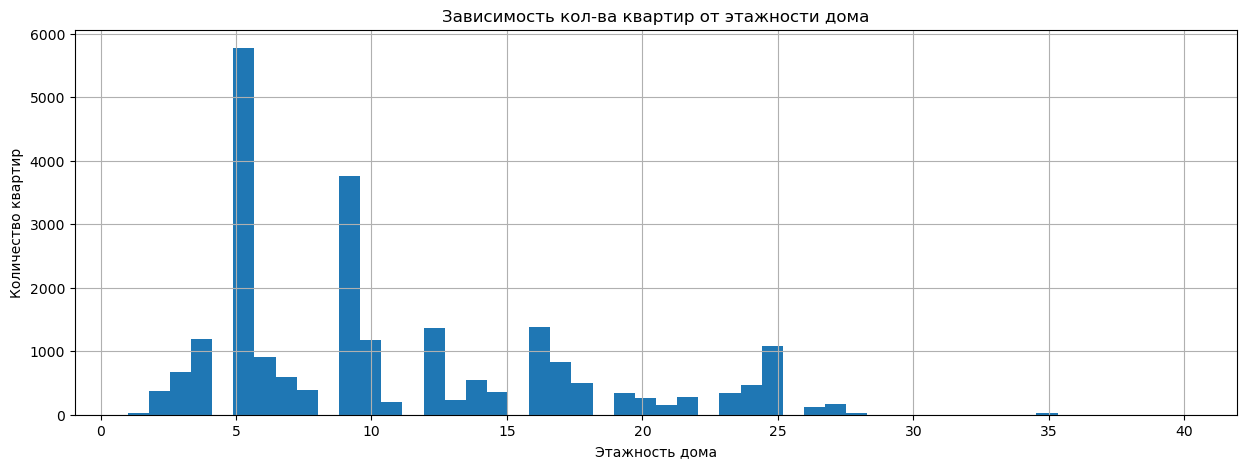

In [125]:
data['floors_total'].plot(kind='hist', bins=50, grid=True, figsize = (15, 5), range=(1,40)) 
plt.ylabel('Количество квартир')
plt.xlabel('Этажность дома')
plt.title('Зависимость кол-ва квартир от этажности дома');

Больше всего предложений с 5-ти и 9-ти этажными квартирами. 

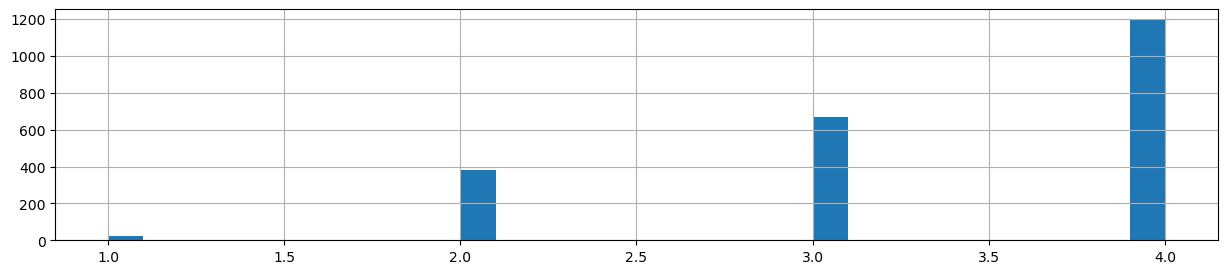

In [126]:
data['floors_total'].hist(bins = 30, figsize = (15,3), range = (1, 4));

Возрастает кол-во квартир на значении 2 этажного дома - начальное значение среза.

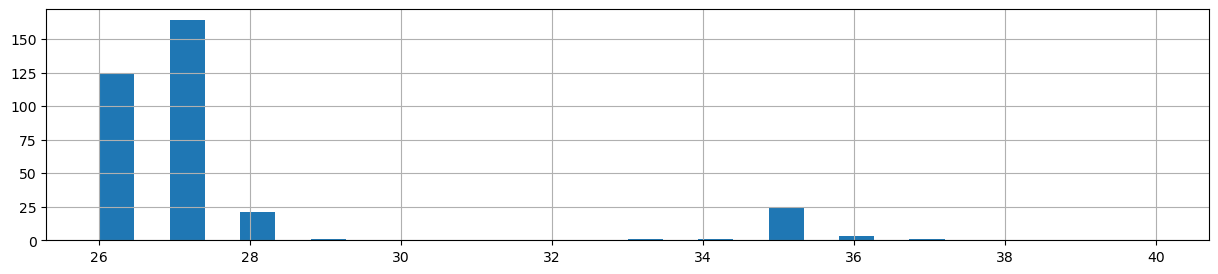

In [127]:
data['floors_total'].hist(bins = 30, figsize = (15,3), range = (26, 40));

Конечное значение - 35.

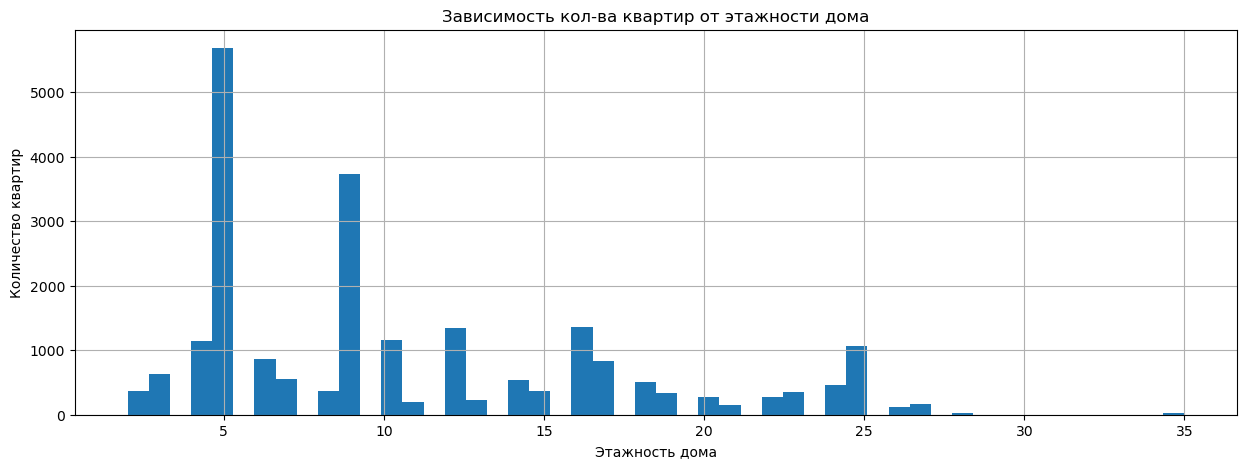

In [128]:
#срез данных без аномалий, сохраняем их в новый датафрейм good_data
good_data = good_data.query('floors_total >= 2 and floors_total <= 35')
good_data['floors_total'].plot(kind='hist', bins=50, grid=True, figsize = (15, 5)) 
plt.ylabel('Количество квартир')
plt.xlabel('Этажность дома')
plt.title('Зависимость кол-ва квартир от этажности дома');

In [129]:
print(len(good_data) / len(data)) 

0.9816669495841114


In [130]:
data['city_centers_km'].describe().round(2) #описательная статистика расстояния до центра

count    18132.00
mean        14.19
std          8.62
min          0.00
25%          9.00
50%         13.00
75%         16.00
max         66.00
Name: city_centers_km, dtype: float64

Медиана от среднего отличается незначительно, т.е. есть выбросы, но они не сильно влияют на данные.

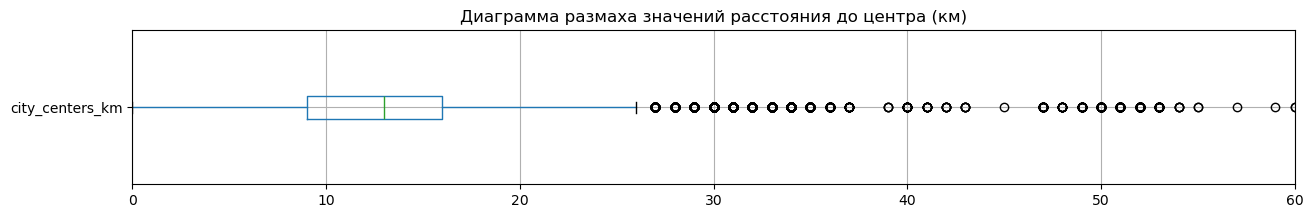

In [131]:
fig, ax = plt.subplots(figsize = (15,2))
ax = data[['city_centers_km']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха значений расстояния до центра (км)')
ax.set_xlim(0, 60);

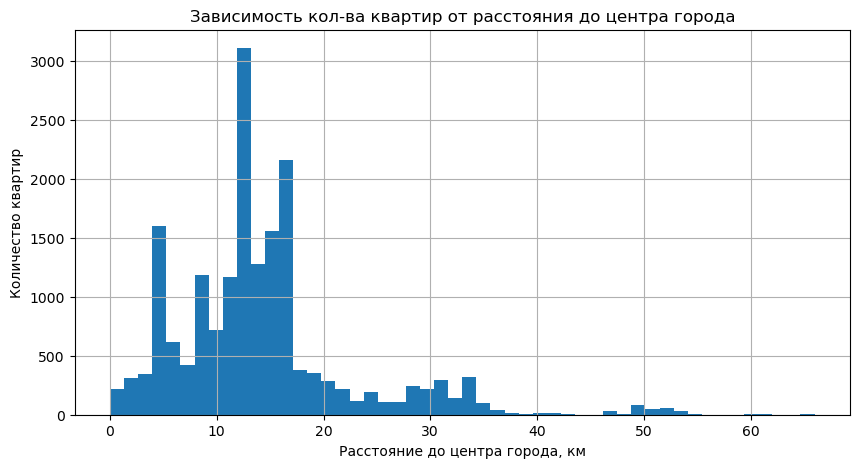

In [132]:
data['city_centers_km'].plot(kind='hist', bins=50, grid=True, figsize = (10, 5), range=(0,66)) 
plt.ylabel('Количество квартир')
plt.xlabel('Расстояние до центра города, км')
plt.title('Зависимость кол-ва квартир от расстояния до центра города');

Большинство квартир удаленностью от центра от 4-17 км. Всплески на 5, 12 и 15 км.

In [133]:
data['parks_nearest'].describe().round(2) #описательная статистика расстояния до парка

count    9625.00
mean      491.02
std       335.40
min         1.00
25%       291.00
50%       456.00
75%       612.00
max      3190.00
Name: parks_nearest, dtype: float64

Медиана от среднего отличается незначительно, т.е. есть выбросы, но они не сильно влияют на данные.

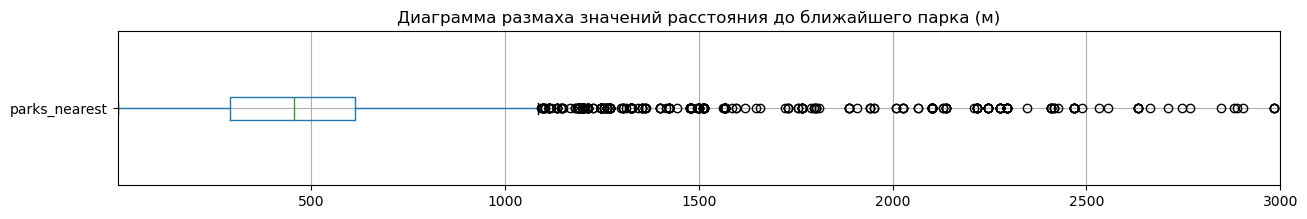

In [134]:
fig, ax = plt.subplots(figsize = (15,2))
ax = data[['parks_nearest']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха значений расстояния до ближайшего парка (м)')
ax.set_xlim(1, 3000);

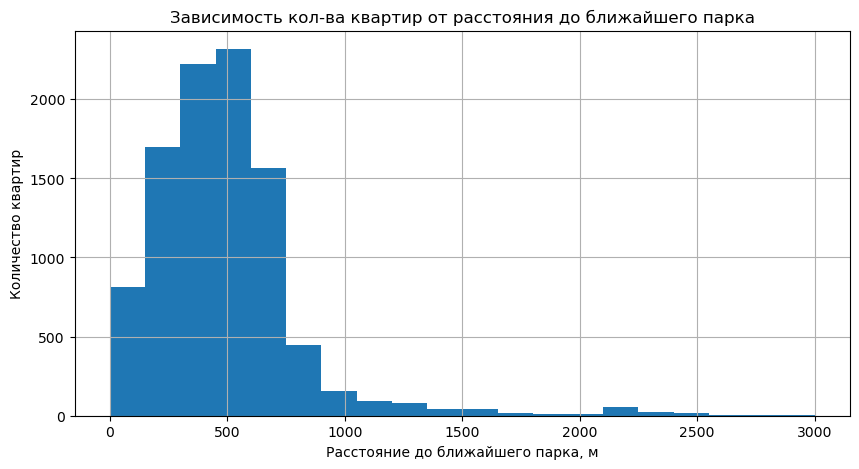

In [135]:
data['parks_nearest'].plot(kind='hist', bins=20, grid=True, figsize = (10, 5), range=(1,3000))
plt.ylabel('Количество квартир')
plt.xlabel('Расстояние до ближайшего парка, м')
plt.title('Зависимость кол-ва квартир от расстояния до ближайшего парка');

В основном представлены квартиры с удаленностью от парка до 750 м. Больше всего квартир с удаленностью в 350-600 метров.

Создали таблицу без редких и выбивающихся значений

In [136]:
(
    good_data[['rooms', 'total_area', 'ceiling_height', 'last_price', 'living_area',  'kitchen_area',
          'floor', 'floors_total', 'city_centers_km', 'parks_nearest']]
    .apply (['count', 'min', 'max', 'median'])   
    .style.format("{:,.2f}")
)

,rooms,total_area,ceiling_height,last_price,living_area,kitchen_area,floor,floors_total,city_centers_km,parks_nearest
count,"23,132.00","23,132.00","23,132.00","23,132.00","23,132.00","23,132.00","23,132.00","23,132.00","17,756.00","9,372.00"
min,0.00,20.00,2.00,"430,000.00",10.00,3.50,1.00,2.00,0.00,1.00
max,7.00,260.00,4.00,"65,000,000.00",200.00,50.00,33.00,35.00,66.00,"3,190.00"
median,2.00,52.00,2.65,"4,600,000.00",30.00,9.60,4.00,9.00,13.00,456.00


In [137]:
# кол-во квартир в пределах нормальных значений
result = good_data.query('rooms <= 6 and floor_type == "средний" and floors_total <= 28 and ceiling_height >= 2.3 \
    and ceiling_height <= 3.2 and total_area <= 120 and living_area <= 80 and kitchen_area <= 22 and last_price <= 16000000 \
    and city_centers_km <= 26 and parks_nearest <= 1100')
result

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,ponds_nearest,days_exposition,name,other_area,price_one,weekday,month,year,floor_type,city_centers_km
2,10,5196000,56.0,2015-08-20,2,2.615,5,34.3,4,False,...,574.0,558.0,Санкт-Петербург,2.17,92785.71,3,8,2015,средний,14.0
9,18,5400000,61.0,2017-02-26,3,2.500,9,43.6,7,False,...,NaN,289.0,Санкт-Петербург,1.74,88524.59,6,2,2017,средний,15.0
10,5,5050000,39.6,2017-11-16,1,2.670,12,20.3,3,False,...,553.0,137.0,Санкт-Петербург,1.93,127525.25,3,11,2017,средний,14.0
15,16,4650000,39.0,2017-11-18,1,2.600,14,20.5,5,False,...,296.0,19.0,Санкт-Петербург,1.85,119230.77,5,11,2017,средний,14.0
18,8,3250000,31.0,2017-01-27,1,2.500,5,19.4,2,False,...,654.0,168.0,Санкт-Петербург,1.16,104838.71,4,1,2017,средний,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23686,8,3300000,31.0,2017-04-29,1,2.550,9,18.0,6,False,...,317.0,193.0,Санкт-Петербург,1.30,106451.61,5,4,2017,средний,12.0
23687,6,3200000,39.0,2017-12-16,1,2.560,9,20.0,6,False,...,NaN,38.0,Санкт-Петербург,1.90,82051.28,5,12,2017,средний,17.0
23688,19,9200000,101.0,2019-04-01,3,3.050,15,63.0,12,False,...,NaN,23.0,Санкт-Петербург,3.80,91089.11,0,4,2019,средний,14.0
23689,13,3550000,35.3,2018-02-28,1,2.860,15,16.3,4,False,...,652.0,29.0,Санкт-Петербург,1.90,100566.57,2,2,2018,средний,16.0


In [138]:
share = len(result) / len(good_data) * 100
share

22.07764136261456

Количество квартир в пределах нормальных значений составляяет 22%.

***Вывод:***
- общая площадь \
гистограмма показала, что в основной массе квартиры имеют метраж от 30-100 кв.м. Больше всего на рынке квартир с общей площадью  31-50 и 60 кв.м.
- жилая площадь \
гистограмма показала, что есть две области массового распределения квартир с метражом 14-20 кв.м. и 26-50 кв.м. Больше всего на рынке квартир с жилой площадью 18, 30 и 44 кв.м. Два пика скорее всего связаны с типом квартиры - студия, однушка, двушка и т.п.
- площадь кухни \
гистограмма показала, что в основной массе квартиры имеют метраж от 5 до 18 кв.м. Больше всего на рынке квартир с площадью кухни 6, 7, 8, 9 и 10 кв.м.
- цена объекта \
гистограмма показала, что в основной массе цена квартиры в пределах 2-8 млн.руб. Больше всего на рынке квартир и имеют цену 3-4 млн.руб.
- количество комнат \
гистограмма показала, что на рынке больше всего 1-3 комнатных квартир. С увеличением числа комнат, кол-во квартир резко снижается.
- высота потолков \
гистограмма показала, что в основной массе квартиры с высотой потолков 2.5-3 м. Самое большое число квартир с высотой примерно  2.50 и 2.75 м. 
- тип этажа квартиры («первый», «последний», «средний») \
гистограмма показала, что квартиры на первом этаже составляют 12% от всего рынка предложений, на последнем этаже - 14%, средние этажи - 74%.
- общее количество этажей в доме \
гистограмма показала, что в основной массе представлены дома с этажностью от 4 до 25 . Больше всего в продаже квартир с этажностью дома в 5 и 9 этажей.
- расстояние до центра города в метрах \
гистограмма показала, что в основной массе квартиры имеют удаленность от цента в пределах 4-17 км. Больше всего на рынке квартир с удаленностью в 12-16 и на 5 км. Но имеем в виду, что еще 23% объявлений не указали данные по этому параметру.
- расстояние до ближайшего парка \
гистограмма показала, что в основной массе квартиры имеют удаленность от парка до 750 м. Больше всего квартир с удаленностью в 350-600 метров. Но имеем в виду, что еще 59% объявлений не указали данные по этому параметру.
\
\
Параметры квартир в пределах нормальных значений: общей площадью до 120 кв.м.,  жилой до 80 кв.м.,  кухней до 22 кв.м., до 6 комнат, на "среднем" этаже,  до 29 этажного дома,  с высотой потолков 2.25-3.1 м.,  с ценой до 11 млн.руб., с удаленностью от центра до 26 км,  от парка - до 1100 метров. Количество квартир в пределах нормальных значений составляяет 22%.

### Изучение скорости продажи квартир (столбец days_exposition)

In [139]:
data['days_exposition'].describe() #описательная статистика кол-ва дней объявления

count    20393.000000
mean       180.748541
std        219.735800
min          1.000000
25%         45.000000
50%         95.000000
75%        231.000000
max       1580.000000
Name: days_exposition, dtype: float64

Медиана от среднего отличается, т.е. есть выбросы.

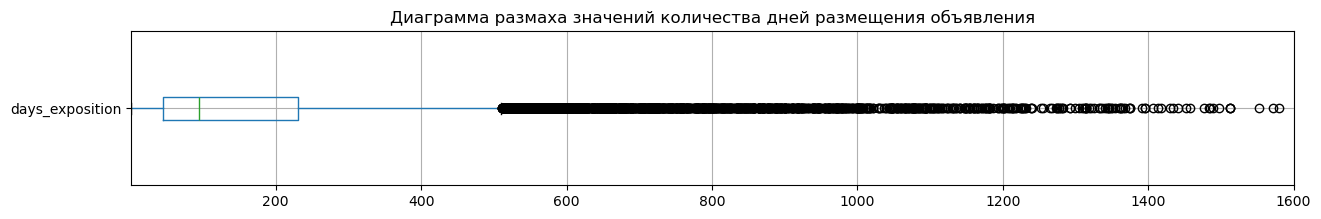

In [140]:
fig, ax = plt.subplots(figsize = (15,2))
ax = data[['days_exposition']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха значений количества дней размещения объявления')
ax.set_xlim(1, 1600);

Выбросы начинаются с 500 дней - сверхдолгие продажи.

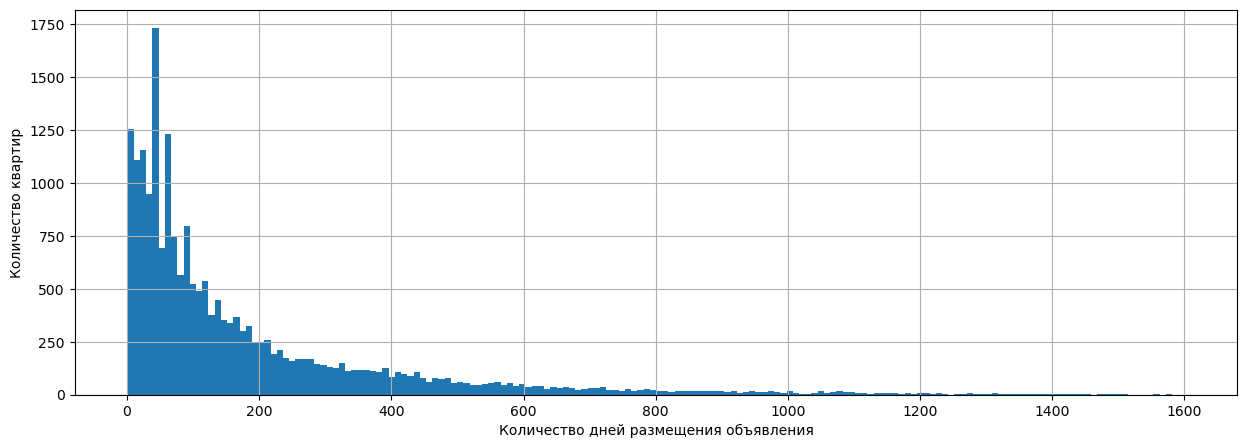

In [141]:
data['days_exposition'].plot(kind='hist', bins=170, grid=True, figsize = (15, 5), range=(1,1600))
plt.ylabel('Количество квартир')
plt.xlabel('Количество дней размещения объявления');

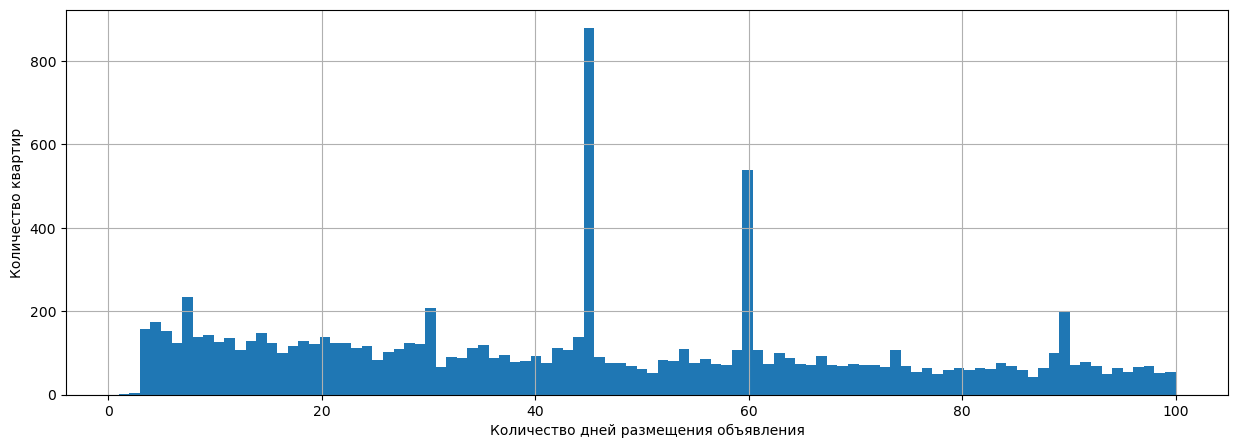

In [142]:
data['days_exposition'].plot(kind='hist', bins=100, grid=True, figsize = (15, 5), range=(1,100))
plt.ylabel('Количество квартир')
plt.xlabel('Количество дней размещения объявления');

Пики на 7, 30, 45, 60 и 90 дней.

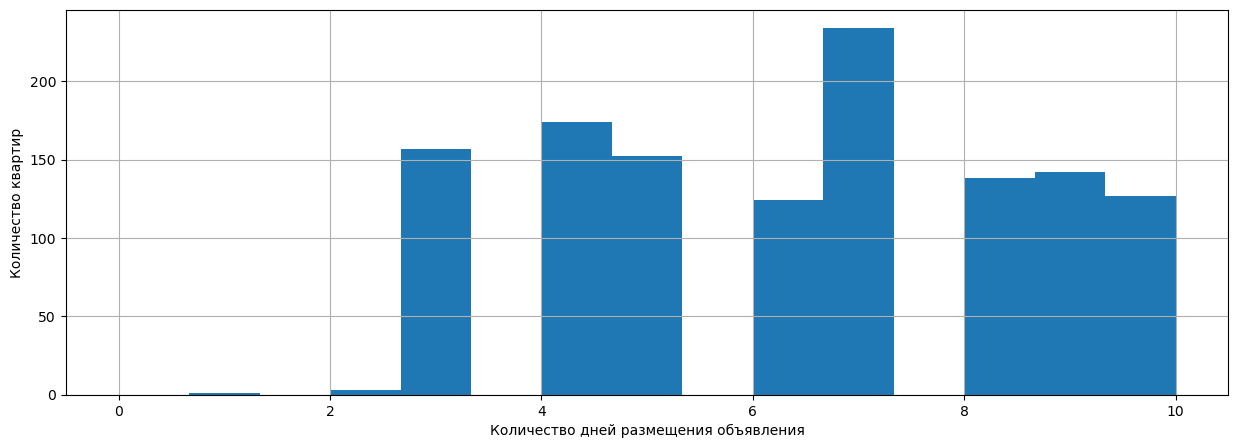

In [143]:
data['days_exposition'].plot(kind='hist', bins=15, grid=True, figsize = (15, 5), range=(0,10))
plt.ylabel('Количество квартир')
plt.xlabel('Количество дней размещения объявления');

Аномальные значения и вначале. Возрастает кол-во квартир на значении 3 дня - начальное значение среза.

In [144]:
data['days_exposition'].value_counts()

days_exposition
45.0      879
60.0      538
7.0       234
30.0      208
90.0      200
         ... 
964.0       1
1147.0      1
1228.0      1
1112.0      1
971.0       1
Name: count, Length: 1139, dtype: int64

Исходя по данным медианы, что более устойчива к выбросам, примерное время продажи квартиры - 95 дней.
А вот среднее значение - 180 дней, т.е. полгода. По boxplot можно сказать, что долгими продажами считаются от 500 дней, а быстрые до 45 дней.
Гистограмма показывает, что объявления чаще всего снимаются с публикации на 45, 60, 7, 30 и 90 дни - похоже на автоматические снятия с публикации. Посмотрю на данные таблицы, что снимаются на 45 день. Но для начало заменю пропуски на значение, больше максимального (max), так как эти пропуски скорее всего связаны, что квартира еще продается или мб она продана, но объявление еще висит.

In [145]:
data['days_exposition'] = data['days_exposition'].fillna(2000).astype('int')# заменены пропуски и изменен тип даных

In [146]:
data.query('days_exposition == 45')

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,...,ponds_nearest,days_exposition,name,other_area,price_one,weekday,month,year,floor_type,city_centers_km
78,9,4350000,37.0,2018-02-22,1,2.650,19,18.000000,6,False,...,NaN,45,Санкт-Петербург,1.900000,117567.57,3,2,2018,средний,14.0
89,9,2500000,63.0,2018-10-25,3,2.500,5,43.000000,4,False,...,NaN,45,поселок,2.000000,39682.54,3,10,2018,средний,NaN
110,6,3850000,72.3,2017-09-29,2,2.700,3,27.400000,2,False,...,NaN,45,деревня,4.490000,53250.35,4,9,2017,средний,NaN
153,12,4350000,55.0,2017-05-21,2,2.570,9,31.200000,2,False,...,NaN,45,другие города,2.380000,79090.91,6,5,2017,средний,34.0
158,15,3100000,47.3,2017-11-07,2,2.550,5,27.500000,2,False,...,NaN,45,поселок,1.980000,65539.11,1,11,2017,средний,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23601,10,2900000,43.4,2018-01-11,2,2.635,5,24.914815,1,False,...,397.0,45,Санкт-Петербург,1.848519,66820.28,3,1,2018,первый,14.0
23613,4,3950000,52.0,2018-03-04,3,2.500,5,31.342466,2,False,...,NaN,45,поселок,2.065753,75961.54,6,3,2018,средний,21.0
23670,9,2450000,45.6,2018-02-08,1,2.800,9,21.533333,2,False,...,NaN,45,поселок,2.406667,53728.07,3,2,2018,средний,NaN
23679,0,2500000,35.0,2017-12-08,1,2.500,9,17.500000,4,False,...,NaN,45,другие города,1.750000,71428.57,4,12,2017,средний,NaN


Никакой зависимости не прослеживается, следовательно, можно считать эти всплески аномальными значениями. 

In [147]:
# ранее очищенная таблица 
print(len(good_data) / len(data)) 

0.9816669495841114


In [148]:
#срез данных, не включая замененные пропуски и аномалии 
good_data_days = good_data.query('days_exposition >= 3 and days_exposition != 45 and days_exposition != 30 and days_exposition != 60 and days_exposition != 90 and days_exposition != 7 and days_exposition != 2000')
print(len(good_data_days) / len(data)) 

0.8090307248344933


Аномалии в столбце 'days_exposition' составляют 20%.

In [149]:
good_data_days['days_exposition'].describe() 

count    19064.000000
mean       186.834295
std        221.880909
min          3.000000
25%         45.000000
50%        103.000000
75%        241.000000
max       1580.000000
Name: days_exposition, dtype: float64

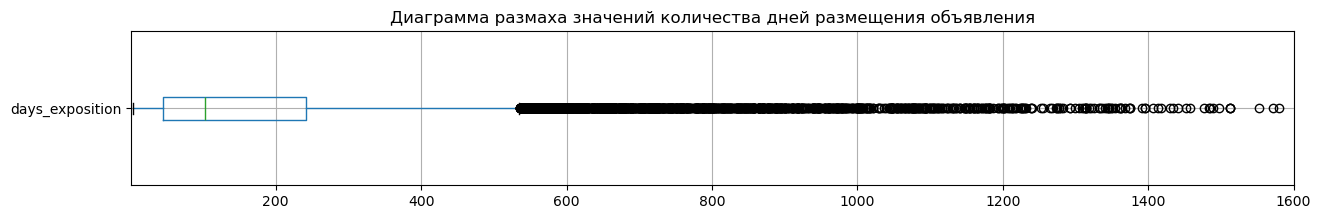

In [150]:
fig, ax = plt.subplots(figsize = (15,2))
ax = good_data_days[['days_exposition']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха значений количества дней размещения объявления')
ax.set_xlim(1, 1600);

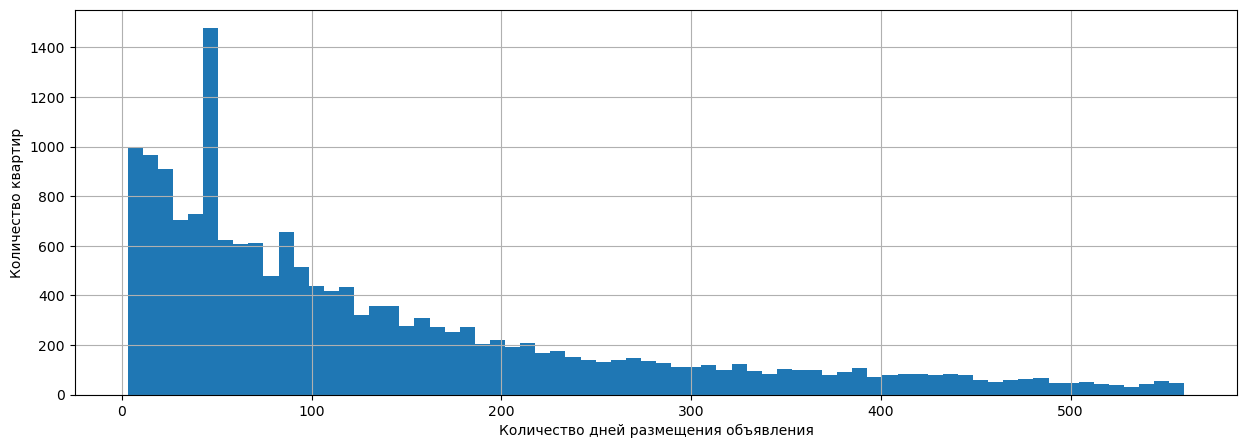

In [151]:
#гистограмма в пределах нормальных значений
good_data_days['days_exposition'].plot(kind='hist', bins=70, grid=True, figsize = (15, 5), range=(3,560))
plt.ylabel('Количество квартир')
plt.xlabel('Количество дней размещения объявления');

In [152]:
good_data_days['days_exposition'].describe()

count    19064.000000
mean       186.834295
std        221.880909
min          3.000000
25%         45.000000
50%        103.000000
75%        241.000000
max       1580.000000
Name: days_exposition, dtype: float64

In [153]:
rate_year = good_data_days.pivot_table(index='year', values='days_exposition') #средней скорости продаж по годам
rate_year 

,days_exposition
year,
2014,909.592920
2015,651.840226
2016,326.724111
2017,163.498449
2018,97.873809
2019,31.267708


In [154]:
rate_year['rate'] = rate_year['days_exposition']/ 365
rate_year

,days_exposition,rate
year,,
2014,909.592920,2.492035
2015,651.840226,1.785864
2016,326.724111,0.895135
2017,163.498449,0.447941
2018,97.873809,0.268147
2019,31.267708,0.085665


***Вывод:***
после очистки данных среднее значение продажи квартиры - 186 дней, медиана - 103 дней. Долгими продажами являются от 241 дня, а вот быстрые продажи до 45 дней. 2017-2018 года показывают нормальную скорость продажи. Самая высокая скорость продажи в 2019 году. И помним, что данный вывод не содержит информацию о еще больше 3000 непроданных квартир.

###  Определение факторов, влияющих на общую (полную) стоимость объекта

Необходимо исследовать следующие параметры: 
- общей площади; 
- жилой площади; 
- площади кухни; 
- количества комнат; 
- этажа, на котором расположена квартира (первый, последний, другой); 
- даты размещения (день недели, месяц, год). 
\
Ранее проведенный анализ показал, что в каждом параметре(столбце) присутствуют выбросы, которые в малой или большой степени влияют на данные. Для примерера подробнее исследуем зависимость цены от общей площади.

In [155]:
good_data['total_area'].describe()

count    23132.000000
mean        58.440481
std         27.610794
min         20.000000
25%         40.000000
50%         52.000000
75%         68.800000
max        260.000000
Name: total_area, dtype: float64

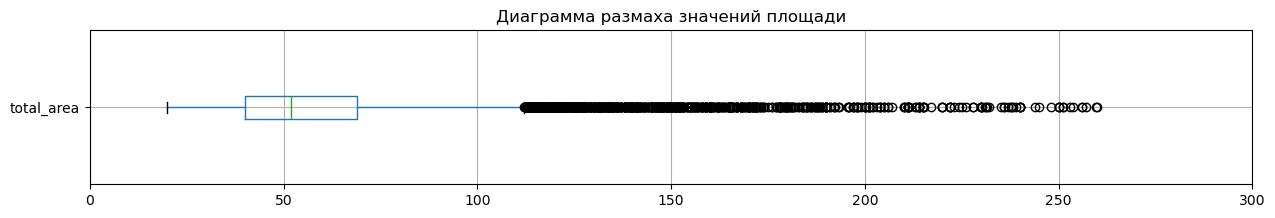

In [156]:
fig, ax = plt.subplots(figsize = (15,2))
ax = good_data[['total_area']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха значений площади')
ax.set_xlim(0, 300);

In [157]:
print('Корреляция до отчистки данных:', data['total_area'].corr(data['last_price']).round(2))
print('Корреляция после отчистки данных:', good_data['total_area'].corr(good_data['last_price']).round(2))

Корреляция до отчистки данных: 0.65
Корреляция после отчистки данных: 0.76


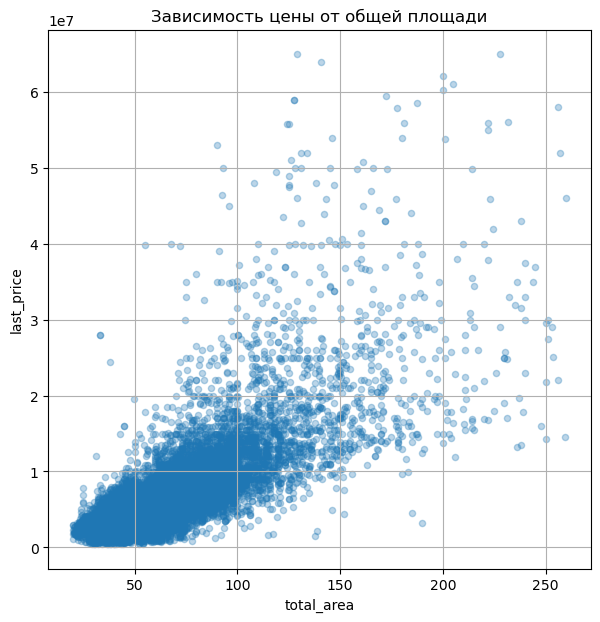

In [158]:
good_data.plot(x='total_area', y='last_price', kind='scatter', grid=True, figsize=(7, 7), alpha=0.3)
plt.title('Зависимость цены от общей площади');

Как видно по диаграмме рассеяния и числу корреляции - связь между общей площадью и ценой есть и после очистки данных корреляция возросла c 0.65 до 0.76. Следовательно, чем больше общая площадь квартиры, тем выше цена. Квартиры до 115 кв.м. в основной массе стоят до 8-18 млн. После 115 кв.м. наблюдаются выбросы и разброс значений.

In [159]:
good_data['living_area'].describe()

count    23132.000000
mean        33.543925
std         18.334371
min         10.000000
25%         18.700000
50%         30.000000
75%         42.000000
max        200.000000
Name: living_area, dtype: float64

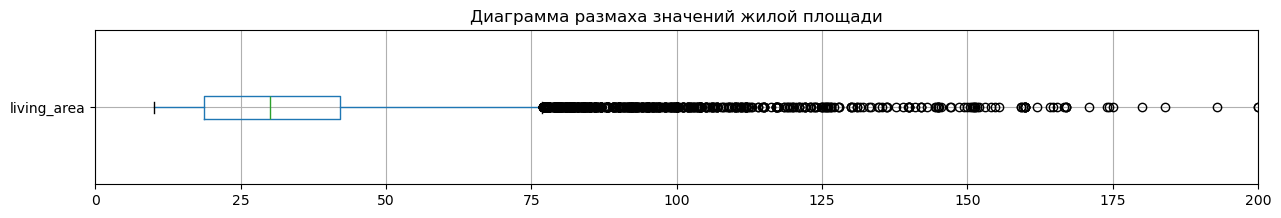

In [160]:
fig, ax = plt.subplots(figsize = (15,2))
ax = good_data[['living_area']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха значений жилой площади')
ax.set_xlim(0, 200);

In [161]:
print('Корреляция до отчистки данных:', data['living_area'].corr(data['last_price']).round(2))
print('Корреляция после отчистки данных:', good_data['living_area'].corr(good_data['last_price']).round(2))

Корреляция до отчистки данных: 0.59
Корреляция после отчистки данных: 0.67


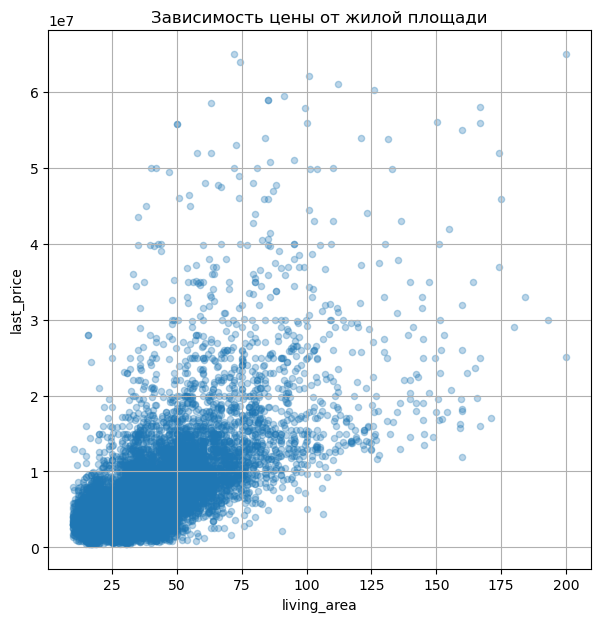

In [162]:
good_data.plot(x='living_area', y='last_price', kind='scatter', grid=True, figsize=(7, 7), alpha=0.3)
plt.title('Зависимость цены от жилой площади');

Как видно по диаграмме рассеяния и числу корреляции - связь между жилой площадью и ценой есть и после очистки данных корреляция возросла с 0.59 до 0.67.  Так как связь между общей площадью и жилой высокая, тогда соответственно, чем больше жилая площадь квартиры, тем выше цена. Но все же на рынке встречаются квартиры с небольшой жилой площадью и высокой ценой. Это могут быть квартиры с большой кухней(не входит в жилую площадь), или же просто дорогостоящие апартаменты, или квартиры свободной планировки. Квартиры с жилой площадью до 80 кв.м. в основной массе стоят до 9-20 млн. После 80 кв.м. наблюдаются выбросы и разброс значений.

In [163]:
good_data['kitchen_area'].describe()

count    23132.000000
mean        11.164494
std          6.025373
min          3.500000
25%          7.200000
50%          9.600000
75%         12.800000
max         50.000000
Name: kitchen_area, dtype: float64

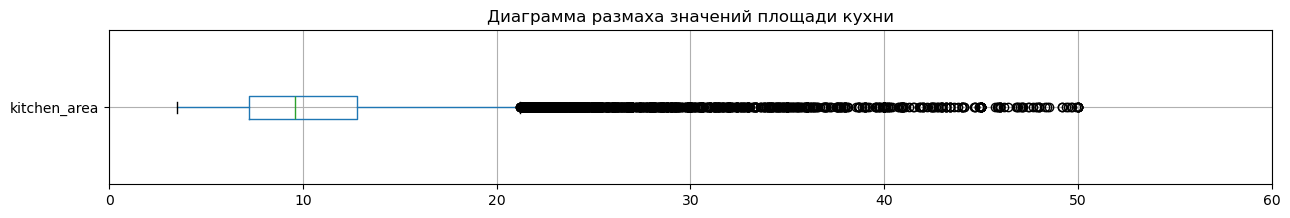

In [164]:
fig, ax = plt.subplots(figsize = (15,2))
ax = good_data[['kitchen_area']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха значений площади кухни')
ax.set_xlim(0, 60);

In [165]:
print('Корреляция до отчистки данных:', data['kitchen_area'].corr(data['last_price']).round(2))
print('Корреляция после отчистки данных:', good_data['kitchen_area'].corr(good_data['last_price']).round(2))

Корреляция до отчистки данных: 0.47
Корреляция после отчистки данных: 0.5


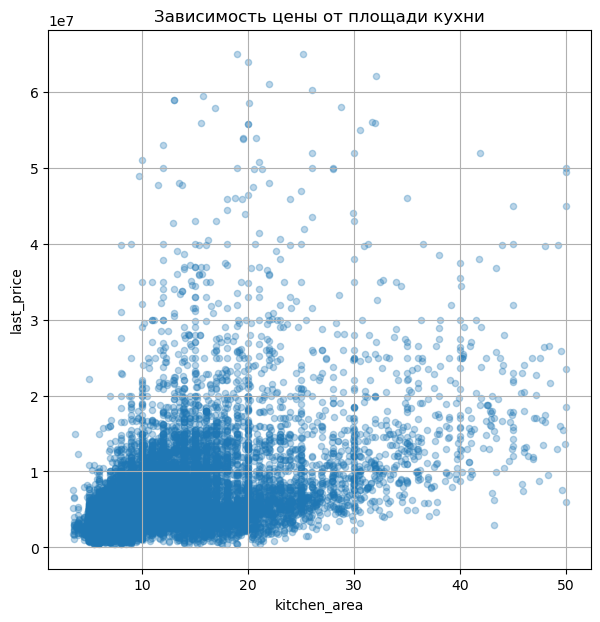

In [166]:
good_data.plot(x='kitchen_area', y='last_price', kind='scatter', grid=True, figsize=(7, 7), alpha=0.3)
plt.title('Зависимость цены от площади кухни');

Корреляция возросла с 0.47 до 0.50, но все же остается слабой. Площадь кухни незначительно влияет на стоимость квартиры.

In [167]:
good_data['rooms'].describe()

count    23132.000000
mean         2.042495
std          1.004878
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          7.000000
Name: rooms, dtype: float64

In [168]:
good_data['rooms'].value_counts().to_frame()

,count
rooms,
1,7926
2,7825
3,5695
4,1125
5,278
0,173
6,74
7,36


In [169]:
print('Корреляция до отчистки данных:', data['rooms'].corr(data['last_price']).round(2))
print('Корреляция после отчистки данных:', good_data['rooms'].corr(good_data['last_price']).round(2))

Корреляция до отчистки данных: 0.36
Корреляция после отчистки данных: 0.47


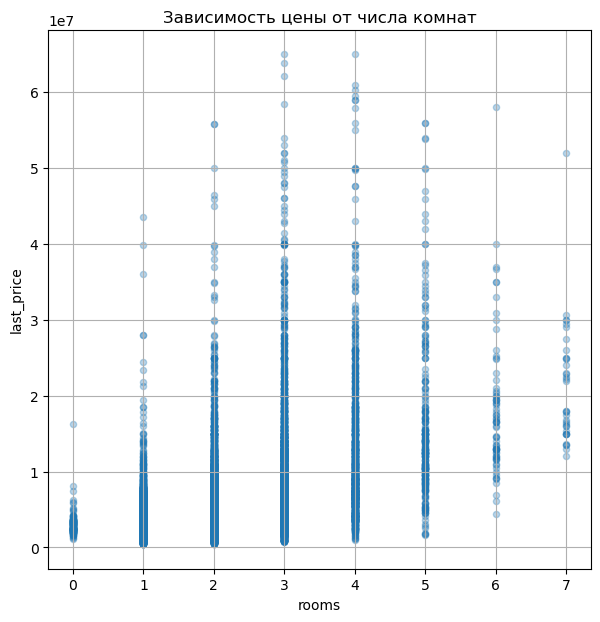

In [170]:
good_data.plot(x='rooms', y='last_price', kind='scatter', grid=True, figsize=(7, 7), alpha=0.3)
plt.title('Зависимость цены от числа комнат');

In [171]:
print('Корреляция между кол-ом комнат и общей площадью:', good_data['rooms'].corr(good_data['total_area']).round(2))

Корреляция между кол-ом комнат и общей площадью: 0.79


Корреляция возросла с 0.36 до 0.47, но все же остается слабой. Как видно по диаграмме цена возрастает до 3-ех комнатных квартир, а после 3-ех комнатных цены снижаются, но не до цен студий (0 комнат), так как все же важную роль играет общая площадь (у 7-ми комнатной квартиры общая площадь будет явно больше студии). А спад цен после 3-ех комнатных квартир свидетельствует, что есть 5-ти комнатные квартиры с общей площадью такой же как и у 3-ех комнатных.

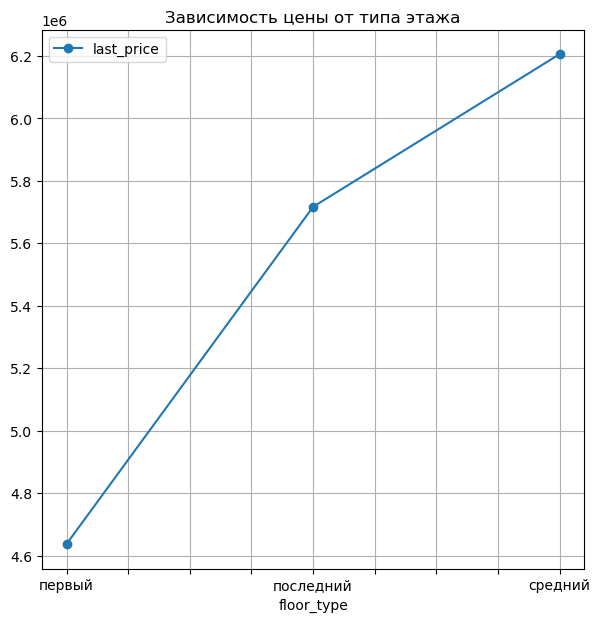

In [172]:
good_data.pivot_table(index='floor_type', values='last_price').plot(grid=True, style='o-', figsize=(7, 7))
plt.title('Зависимость цены от типа этажа');

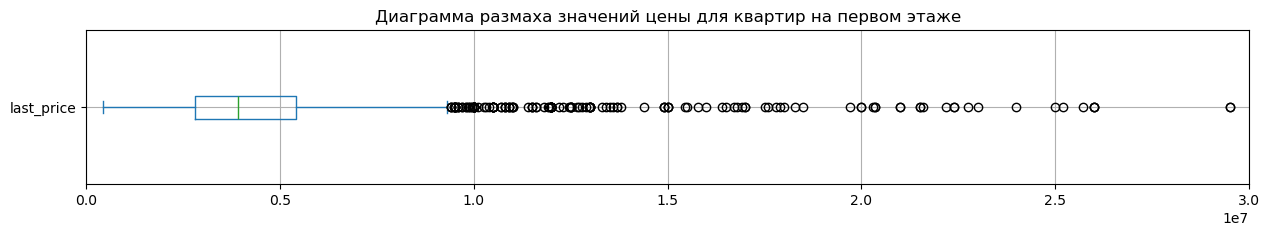

In [173]:
#боксплот для с типом этажа "первый"
fig, ax = plt.subplots(figsize = (15,2))
ax = good_data.query('floor_type == "первый"').plot(y='last_price', kind='box', grid=True, vert = False, ax =ax)
ax.set_title('Диаграмма размаха значений цены для квартир на первом этаже')
ax.set_xlim(0, 30000000);

Межквартальный размах для квартир на первом этаже от 500 тыс.руб. до 9 млн. Медиана на 3.9 млн.руб.

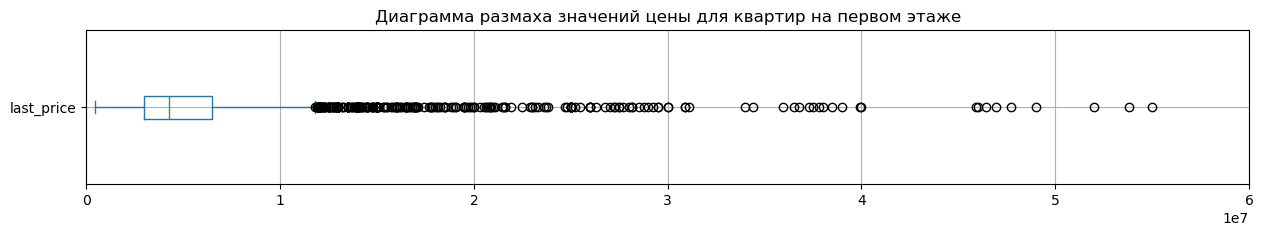

In [174]:
#боксплот для с типом этажа "последний"
fig, ax = plt.subplots(figsize = (15,2))
ax = good_data.query('floor_type == "последний"').plot(y='last_price', kind='box', grid=True, vert = False, ax =ax)
ax.set_title('Диаграмма размаха значений цены для квартир на первом этаже')
ax.set_xlim(0, 60000000);

Межквартальный размах для квартир на последнем этаже от 1 до 12 млн. Медиана на 4 млн.руб.

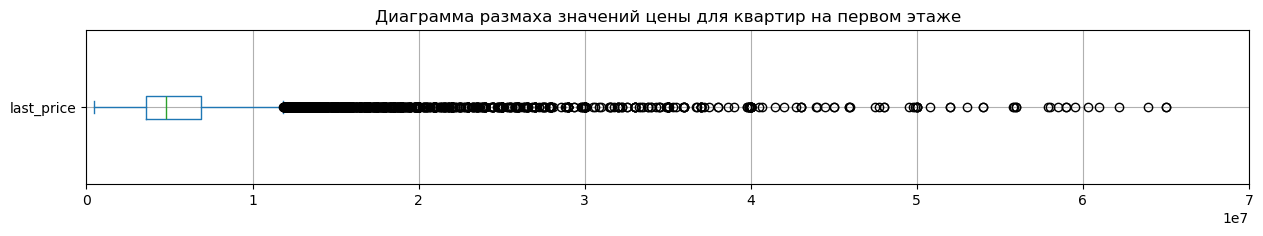

In [175]:
#боксплот для с типом этажа "средний"
fig, ax = plt.subplots(figsize = (15,2))
ax = good_data.query('floor_type == "средний"').plot(y='last_price', kind='box', grid=True, vert = False, ax =ax)
ax.set_title('Диаграмма размаха значений цены для квартир на первом этаже')
ax.set_xlim(0, 70000000);

Межквартальный размах для квартир на средних этажах от 1 до 12 млн. Медиана на 4.8 млн.руб.

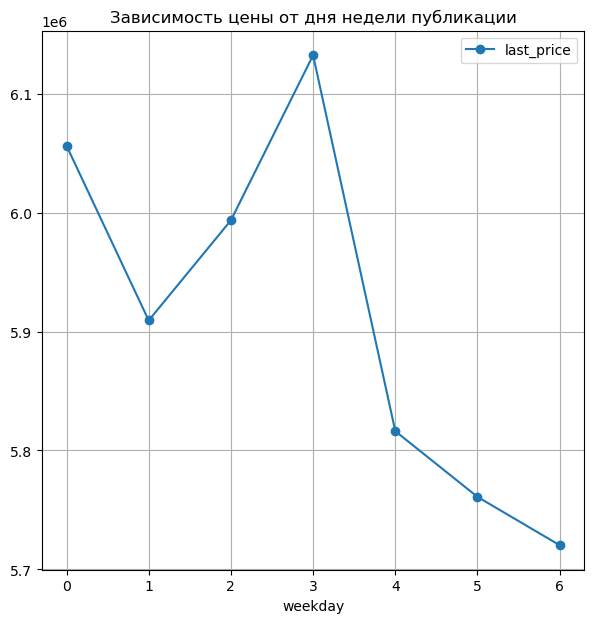

In [176]:
good_data.pivot_table(index='weekday', values='last_price').plot(grid=True, style='o-', figsize=(7, 7))
plt.title('Зависимость цены от дня недели публикации');

In [177]:
print('Корреляция до отчистки данных:', data['weekday'].corr(data['last_price']).round(2))
print('Корреляция после отчистки данных:', good_data['weekday'].corr(good_data['last_price']).round(2))

Корреляция до отчистки данных: 0.0
Корреляция после отчистки данных: -0.02


Корреляция отсутствует, а после отчистки данных показывает крайне слабую отрицательную. В целом, в будни цены выше, чем в выходные дни. По четвергам самые высокие цены, по воскресеньям самые низкие. В выходные сложности с обналичиванием денег в банках, следовательно платежеспособность клиентов ниже. Да и в выходные продавцы/риелторы/покупатели по большей части отдыхают, т.е. спрос меньше.

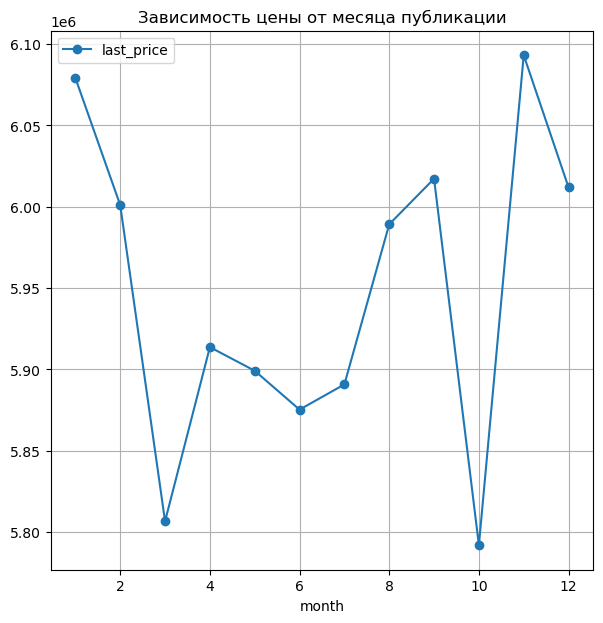

In [178]:
good_data.pivot_table(index='month', values='last_price').plot(grid=True, style='o-', figsize=(7, 7))
plt.title('Зависимость цены от месяца публикации');

In [179]:
print('Корреляция до отчистки данных:', data['month'].corr(data['last_price']).round(2))
print('Корреляция после отчистки данных:', good_data['month'].corr(good_data['last_price']).round(2))

Корреляция до отчистки данных: 0.0
Корреляция после отчистки данных: 0.0


Корреляция отсутствует. Под конец года цены чуть выше, чем в начале и это нормально, ведь цены растут из года в год. Резкий спад с февраль-март и сентябрь-октябрь, а в ноябре самые высокие цены.
Высокие цены на недвижимость в начале года, перед праздником Новым Годом и период август-сентябрь (больше студентов).

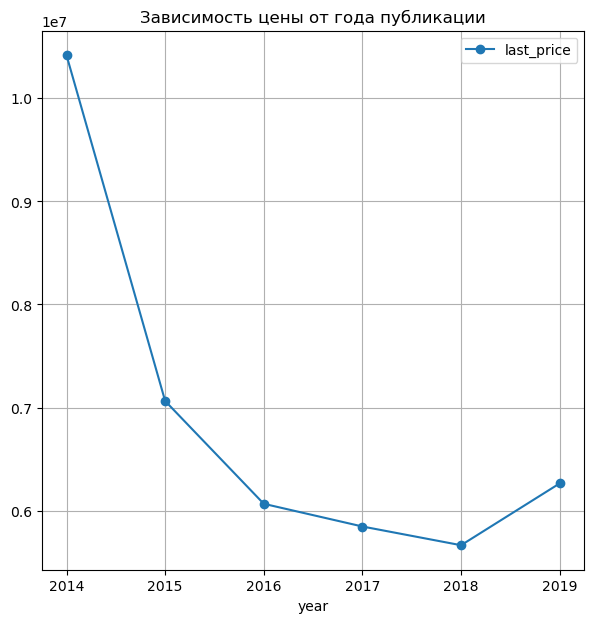

In [180]:
good_data.pivot_table(index='year', values='last_price').plot(grid=True, style='o-', figsize=(7, 7))
plt.title('Зависимость цены от года публикации');

In [181]:
good_data.pivot_table(index='year', values='last_price')

,last_price
year,
2014,1.041532e+07
2015,7.064678e+06
2016,6.068510e+06
2017,5.848496e+06
2018,5.667081e+06
2019,6.266269e+06


In [182]:
print('Корреляция до отчистки данных:', data['year'].corr(data['last_price']).round(2))
print('Корреляция после отчистки данных:', good_data['year'].corr(good_data['last_price']).round(2))

Корреляция до отчистки данных: -0.04
Корреляция после отчистки данных: -0.04


Корреляция крайне слабая отрицательная. Наблюдается резкий спад в кризисные года с 2014 по 2016 и дальнейшее слабое падение до 2018 года. После 2018 цены уже начали расти.

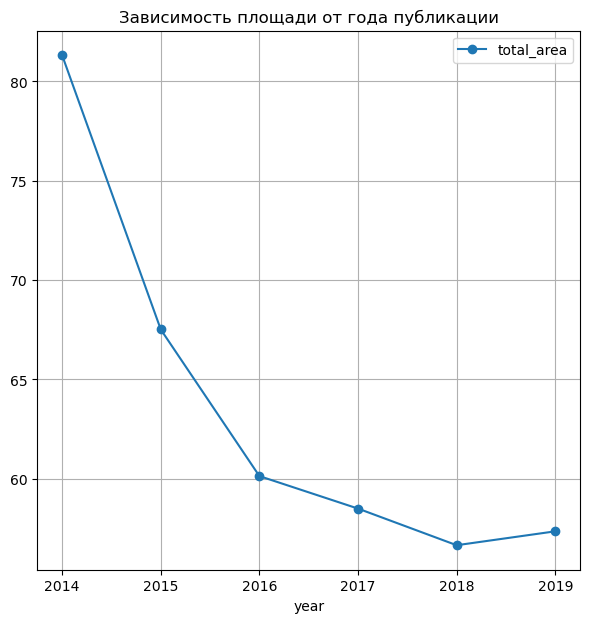

In [183]:
good_data.pivot_table(index='year', values='total_area').plot(grid=True, style='o-', figsize=(7, 7))
plt.title('Зависимость площади от года публикации');

In [184]:
good_data.pivot_table(index='year', values='total_area', aggfunc=['mean','count'])

,mean,count
,total_area,total_area
year,,
2014,81.320840,131
2015,67.506401,1131
2016,60.121273,2702
2017,58.483887,8000
2018,56.639292,8347
2019,57.339770,2821


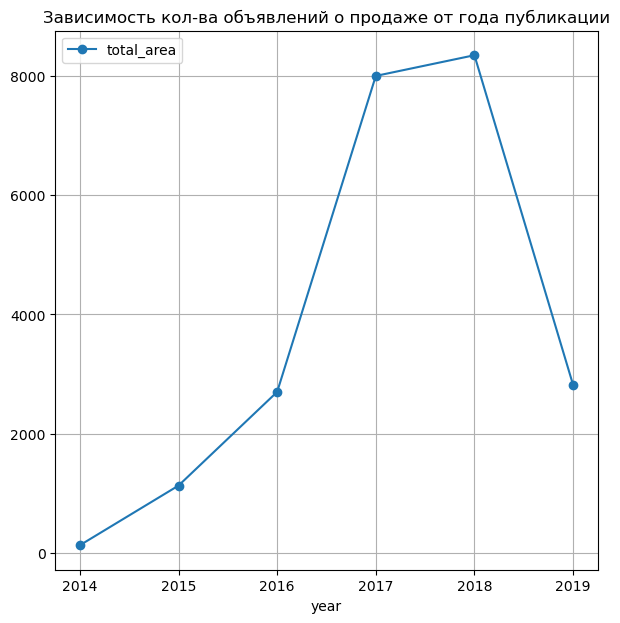

In [185]:
good_data.pivot_table(index='year', values='total_area', aggfunc='count').plot(grid=True, style='o-', figsize=(7, 7))
plt.title('Зависимость кол-ва объявлений о продаже от года публикации');

Так как на цену квартиры влияет площадь, а мы видим, что с каждым годом до 2018 года на продажу выставлялись квартиры с меньшей площадью, а кол-во объявлений росло, то и цена понижалась. В кризисные года кол-во объявлений о продаже резко подскочило, рынок переполнен, цены падают. С 2018 цены начинают расти на ту же площадь, но кол-во объявлений значительно ниже. Однако, на цену влиеет и локация, и в разные годы могло быть больше квартир из определенной (дешевой или дорогой) локации.

***Вывод:*** 

На цену влияют следующие параметры:
- общая площадь и жилая
- площадь кухни влияет на цену, но незначительно 
- число комнат, влияющее на площадь квартиры, однако зависимость невысока, так как встречаются квартиры с меньшим числом комнат, но с большей площадью
- тип этажа. Средняя цена за квартиры на первых этажах значительно ниже относительно средних этажей. На последних этажах немного выше относительно квартир на первых этажах. Высокий ценовой диапазон в пределах нормальных значений принадлежит квартирам на средних этажах
- кол-во объявлений
- локация 

День недели публикации не влияет на цену квартиры. Но наблюдается, что в будни цены выше, чем в выходные дни. Возможно влияние "третьего" фактора. Аналогично параметры - месяц и год. 
Месяц публикации тоже не влияет на цену квартиры. Но наблюдается, что под конец года цены чуть выше, чем в начале и это нормально, ведь цены обычно растут из года в год. "Третьим" фактором могут быть события или праздники. 
Год публикации в данном отрезке времени показывает слабую отрицательную корреляцию из-за кризисного периода.

### Посчитать среднюю цену одного квадратного метра в 10 населённых пунктах с наибольшим числом объявлений — построить сводную таблицу с количеством объявлений и средней ценой квадратного метра для этих населенных пунктов. Выделить населённые пункты с самой высокой и низкой стоимостью квадратного метра

In [186]:
#сводная таблица с ценами по населенным пунктам
count_name = good_data.pivot_table(index = 'locality_name', values = 'last_price', aggfunc='count')
count_name.columns = ['count']
#отсортирована по убыванию таблица по столбцу 'count
count_name = count_name.sort_values(by = 'count', ascending=False) 
count_name.head(10)

,count
locality_name,
Санкт-Петербург,15296
поселок Мурино,542
поселок Шушары,437
Всеволожск,397
Пушкин,362
Колпино,337
поселок Парголово,326
Гатчина,306
деревня Кудрово,298


Больше всего публикаций о продаже квартир в Санкт-Петербурге. В выборке из 10 населенных пунктов последнее место по числу объявлений занимает г.Выборг.

In [187]:
count_name['price_one'] = good_data.pivot_table(index = 'locality_name', values = 'price_one', aggfunc='mean').round(0)
#сводная таблица средней стоимости 1 кв.м. по населенному пункту, отсортированная по убыванию кол-ва объявлений
count_name_count = count_name.sort_values(by = 'count', ascending=False).head(10) 
count_name_count

,count,price_one
locality_name,,
Санкт-Петербург,15296,112384.0
поселок Мурино,542,85420.0
поселок Шушары,437,78555.0
Всеволожск,397,68606.0
Пушкин,362,102815.0
Колпино,337,75333.0
поселок Парголово,326,90332.0
Гатчина,306,68758.0
деревня Кудрово,298,92516.0


In [188]:
count_name_count.sort_values(by = 'price_one', ascending=False)

,count,price_one
locality_name,,
Санкт-Петербург,15296,112384.0
Пушкин,362,102815.0
деревня Кудрово,298,92516.0
поселок Парголово,326,90332.0
поселок Мурино,542,85420.0
поселок Шушары,437,78555.0
Колпино,337,75333.0
Гатчина,306,68758.0
Всеволожск,397,68606.0


In [189]:
str_max = count_name_count[count_name_count['price_one']==count_name_count['price_one'].max()]
str_max 

,count,price_one
locality_name,,
Санкт-Петербург,15296,112384.0


In [190]:
str_min = count_name_count[count_name_count['price_one']==count_name_count['price_one'].min()]
str_min 

,count,price_one
locality_name,,
Выборг,236,58094.0


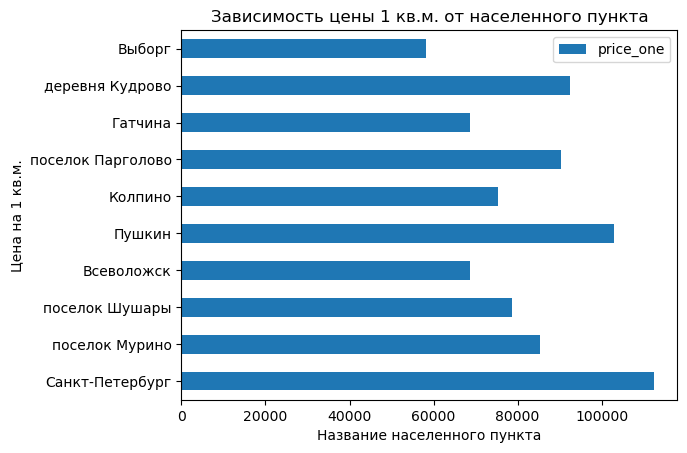

In [191]:
count_name_count.plot(y='price_one', kind='barh')
plt.ylabel('Цена на 1 кв.м.')
plt.xlabel('Название населенного пункта')
plt.title('Зависимость цены 1 кв.м. от населенного пункта');

***Вывод:***

Больше всего публикаций в Санкт-Петербурге, меньше всего - в Выборге. 
Самая высокая средняя цена за 1 кв.метр в Санкт-Петербурге - 112384 тыс.руб, а самая маленькая - в Выборге - 58094 тыс.руб.

### Выделить квартиры в Санкт-Петербурге с помощью столбца locality_name и вычислить их среднюю стоимость на разном удалении от центра в км - для каждого км. Описать, как стоимость объектов зависит от расстояния до центра города — построить график изменения средней цены для каждого километра от центра Петербурга.


In [192]:
#срез по квартирам в Санкт-Петербурге, вывела описательную статистику расстояний до центра города
city_centers_spb = good_data.query('locality_name == "Санкт-Петербург"')['city_centers_km'].describe() 
city_centers_spb

count    15296.000000
mean        11.681943
std          4.799597
min          0.000000
25%          8.000000
50%         12.000000
75%         15.000000
max         29.000000
Name: city_centers_km, dtype: float64

In [193]:
city_centers_spb = good_data.query('locality_name == "Санкт-Петербург"').pivot_table(index='city_centers_km', values='last_price')
#сводная таблица средней стоимости  квартиры в зависимости от расстояния до центра города, отсортированная по убыванию 
city_centers_spb.sort_values(by = 'last_price', ascending=False) 

,last_price
city_centers_km,
0.0,2.298960e+07
1.0,1.309719e+07
2.0,1.257557e+07
7.0,1.202995e+07
6.0,1.171954e+07
5.0,1.169406e+07
4.0,1.109067e+07
3.0,1.013158e+07
8.0,9.023297e+06


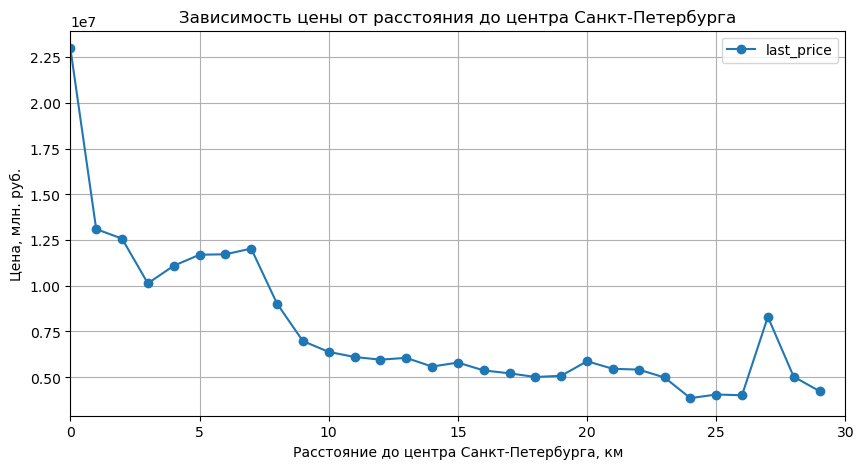

In [194]:
(
    good_data.query('locality_name == "Санкт-Петербург"')
    .pivot_table(index='city_centers_km', values='last_price')
    .plot(grid=True, style='o-', xlim=(0,30), figsize=(10, 5))
)
plt.title('Зависимость цены от расстояния до центра Санкт-Петербурга')
plt.xlabel('Расстояние до центра Санкт-Петербурга, км')
plt.ylabel('Цена, млн. руб.');

In [195]:
print('Корреляция до отчистки данных:', data['city_centers_km'].corr(data['last_price']).round(2))
print('Корреляция после отчистки данных:', good_data['city_centers_km'].corr(good_data['last_price']).round(2))

Корреляция до отчистки данных: -0.21
Корреляция после отчистки данных: -0.33


In [196]:
pd.set_option('display.max_columns', None) # выводим все столбцы
good_data.loc[good_data['city_centers_km'] == 27].head(20)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,name,other_area,price_one,weekday,month,year,floor_type,city_centers_km
109,2,7497600,62.5,2015-12-08,2,2.60,5,35.5000,5,False,False,False,9.50000,0,Пушкин,14.52,26670.0,1.0,517.0,0.0,NaN,1048.0,другие города,2.70000,119961.60,1,12,2015,последний,27.0
140,8,16912000,105.7,2016-12-09,2,2.70,3,48.4000,1,False,False,False,15.40000,0,Пушкин,14.35,26506.0,3.0,366.0,3.0,179.0,390.0,другие города,5.73000,160000.00,4,12,2016,первый,27.0
439,9,8570000,72.0,2018-08-11,3,3.00,6,42.0000,4,False,False,False,10.00000,0,Пушкин,14.69,26845.0,0.0,NaN,0.0,NaN,149.0,другие города,3.00000,119027.78,5,8,2018,средний,27.0
556,0,3500000,28.5,2018-06-06,1,2.50,5,16.0000,4,False,False,False,5.00000,1,Пушкин,14.85,27006.0,0.0,NaN,0.0,NaN,86.0,другие города,1.25000,122807.02,2,6,2018,средний,27.0
558,13,4500000,65.5,2017-10-27,3,2.60,10,42.0000,7,False,False,False,8.00000,2,поселок Металлострой,25.53,27243.0,0.0,NaN,0.0,NaN,32.0,поселок,2.35000,68702.29,4,10,2017,средний,27.0
748,13,14350000,74.0,2017-11-28,2,3.13,5,30.0000,3,False,False,False,25.00000,0,Санкт-Петербург,23.89,27313.0,1.0,1496.0,0.0,NaN,128.0,Санкт-Петербург,4.40000,193918.92,1,11,2017,средний,27.0
931,8,6650000,69.0,2017-06-20,3,3.20,3,50.0000,2,False,False,False,7.00000,0,Пушкин,14.95,27104.0,1.0,27.0,0.0,NaN,261.0,другие города,1.90000,96376.81,1,6,2017,средний,27.0
1138,1,8000000,84.4,2017-08-22,3,2.50,4,60.0000,1,False,False,False,9.60000,0,Пушкин,14.53,26681.0,3.0,398.0,3.0,213.0,584.0,другие города,2.44000,94786.73,1,8,2017,первый,27.0
1675,4,3300000,31.0,2017-02-20,1,2.50,4,17.0000,3,False,False,False,5.00000,0,Пушкин,14.53,26681.0,3.0,398.0,3.0,213.0,651.0,другие города,1.40000,106451.61,0,2,2017,средний,27.0
1719,12,4200000,38.0,2018-02-12,1,2.70,4,17.0000,3,False,False,False,9.00000,1,Пушкин,14.98,27136.0,3.0,311.0,3.0,557.0,162.0,другие города,2.10000,110526.32,0,2,2018,средний,27.0


На 27 км находится исторический город Пушкин, поэтому цена на недвижимость выше, чем в соседних городах/районах. Этот город крупный туристический, научный, учебный и военно-промышленный центр и включён в список памятников, охраняемых ЮНЕСКО. Недвижимость большой площади с высокими потолками. 

In [197]:
table = good_data.pivot_table(index = ['city_centers_km', 'floor_type'], values = 'last_price', aggfunc='count').round(0)
table.columns = ['count']
table.head(24)

count
city_centers_km floor_type       
0.0             первый          3
                последний       4
                средний        14
1.0             первый         22
                последний      39
                средний       109
2.0             первый         44
                последний      72
                средний       163
3.0             первый         53
                последний      77
                средний       202
4.0             первый         75
                последний     107
                средний       474
5.0             первый         76
                последний     130
                средний       656
6.0             первый         64
                последний      82
                средний       427
7.0             первый         32
                последний      57
                средний       307

Подробнее рассмотрим квартиры в центре. На графике мы видим резкий спад на 1 км и 3 км. Размер доли категорий квартир с более дешевой стоимостью намного больше на 3-м километре, чем на пятом, что является одной из причин падения и пика.\
На 4-7 км видим повышение в цене и кол-во квартир больше. Если рассмотреть этом километраж, то заметим, что появляются высокие новостройки - это следствие подорожания и увеличения кол-ва квартир на рынке недвижимости. 

In [198]:
good_data.loc[good_data['city_centers_km'] == 4].head(20)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,name,other_area,price_one,weekday,month,year,floor_type,city_centers_km
35,6,15500000,149.0,2017-06-26,5,2.615,5,104.000000,4,False,False,False,17.000000,0,Санкт-Петербург,23.67,3502.0,0.0,NaN,1.0,779.0,644.0,Санкт-Петербург,4.500000,104026.85,0,6,2017,средний,4.0
61,18,7990000,74.0,2017-08-24,2,4.000,4,43.000000,4,False,False,False,20.000000,0,Санкт-Петербург,22.57,4288.0,1.0,363.0,0.0,660.0,609.0,Санкт-Петербург,3.100000,107972.97,3,8,2017,последний,4.0
121,20,33000000,180.0,2017-02-17,3,2.900,9,86.000000,8,False,False,False,24.000000,4,Санкт-Петербург,25.69,4264.0,1.0,633.0,0.0,NaN,144.0,Санкт-Петербург,9.400000,183333.33,4,2,2017,средний,4.0
136,16,6500000,51.8,2018-08-01,2,3.450,6,25.600000,2,False,False,False,7.300000,1,Санкт-Петербург,20.50,3618.0,2.0,533.0,1.0,812.0,163.0,Санкт-Петербург,2.620000,125482.63,2,8,2018,средний,4.0
137,11,13310800,85.1,2018-01-01,2,2.700,10,31.520000,5,False,False,False,26.850000,1,Санкт-Петербург,31.46,4263.0,1.0,141.0,3.0,133.0,340.0,Санкт-Петербург,5.358000,156413.63,0,1,2018,средний,4.0
147,10,27700000,179.6,2017-07-06,5,2.850,25,97.200000,25,False,False,False,33.800000,2,Санкт-Петербург,19.42,4489.0,0.0,NaN,1.0,806.0,75.0,Санкт-Петербург,8.240000,154231.63,3,7,2017,последний,4.0
291,10,5900000,70.0,2017-01-24,3,2.510,5,47.400000,1,False,False,False,8.000000,0,Санкт-Петербург,19.86,4132.0,1.0,469.0,1.0,118.0,480.0,Санкт-Петербург,2.260000,84285.71,1,1,2017,первый,4.0
305,12,6283000,70.8,2017-10-05,3,3.110,5,50.900000,5,False,False,False,8.200000,0,Санкт-Петербург,25.34,4235.0,0.0,632.0,0.0,434.0,61.0,Санкт-Петербург,1.990000,88742.94,3,10,2017,последний,4.0
315,8,13900000,108.0,2018-09-29,4,3.110,6,76.900000,2,False,False,False,11.200000,0,Санкт-Петербург,25.30,3876.0,1.0,320.0,0.0,325.0,156.0,Санкт-Петербург,3.110000,128703.70,5,9,2018,средний,4.0
486,8,6650000,73.0,2015-08-20,2,3.300,4,49.000000,4,False,False,False,21.600000,0,Санкт-Петербург,20.50,3621.0,3.0,416.0,1.0,638.0,638.0,Санкт-Петербург,2.400000,91095.89,3,8,2015,последний,4.0


***Вывод:***

Чем ближе квартира к центру и меньше предложений, тем дороже ее стоимость. Самые дорогие квартиры в центре города - до 7 км, после наблюдается спад цены. Цена в центре города от 12 до 22 млн.руб. Квартиры на расстоянии 8-23 км имеют стоимость 9-5 млн. Далее стоимость снижается примерно до 4 млн.руб. На 27 км наблюдается небольшое повышение цены до 8.3 млн из-за исторического  и туристического города Пушкина.

## Напишите общий вывод

В целях определения параметров, влияющих на цену объектов недвижимости, были проанализированы данные объявлений в сервисе Яндекс Недвижимость о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет. 

На этапе предобработки данных было выявлено большое количество пропусков, связанных с человеческим фактором, некорректной работой геосервисов и, возможно, с техническим сбоем. Число пропусков сократили с 19% до 9%. Так же были устранены аномальные значения и изменен тип данных по некоторым столбцам. Явные дубликаты отсутствовали.

Рекомендуется наладить работу геосервисов и присвоить статусы полям обязательных для заполнения. 

В результате исследования были определены параметры, влияющие на стоимость объекта недвижимости:
-	общая площадь – больше всех остальных параметров влияет на ценообразование объекта. Чем больше общая площадь, тем больше стоимость квартиры;
-	жилая площадь – так как жилая площадь зависит от общей, то в основной массе: чем больше жилая площадь квартиры, тем выше цена. Но на рынке встречаются квартиры с небольшой жилой площадью и высокой ценой. Это могут быть квартиры с большой кухней(не входит в жилую площадь), или же просто дорогостоящие апартаменты, или квартиры свободной планировки;
-   площадь кухни незначительно влияет на стоимость объекта;
-	число комнат – параметр, влияющий на площадь квартиры, однако зависимость невысока, так как встречаются квартиры с меньшим числом комнат, но с большей площадью;
-	тип этажа – самый востребованный и чаще встречаемый вариант квартиры на "средних" этажах (не последних и не на первых), от чего стоимость таких квартир выше. Квартиры на первых этажах стоят дешевле всего. На последних этажах немного выше относительно квартир на первых этажах;
-	кол-во объявлений в текущей момент;
-	расстояние до центра Санкт-Петербурга - чем ближе квартира к центру, тем меньше предолжений и тем дороже ее стоимость. Самые дорогие квартиры в центре города - до 7 км - от 12 до 22 млн.руб. Квартиры на расстоянии 8-23 км имеют стоимость 9-5 млн. Далее стоимость снижается примерно до 4 млн.руб. На 27 км наблюдается небольшое повышение цены до 8.3 млн из-за исторического и туристического города Пушкина.

В ходе анализа установили важные инсайты: 
- день недели публикации - в будни цены выше, чем в выходные дни;
- месяц публикации - под конец года цены чуть выше, чем в начале;
- в кризисные года цены на недвижимость падают, а восстанавливается рынок через 2-3 года;
- на формирование цены большое влияние оказывают различные "третьи" факторы, например, масштабные праздники и события;
- среднее время продажи квартиры от 3 до 7 месяцев.  Долгими продажами являются от 241 дня, а вот быстрые продажи до 45 дней;
- количество квартир в пределах нормальных значений составляяет 22%;
- больше всего публикаций о продаже квартир в Санкт-Петербурге. Там же и самая высокая средняя цена за 1 кв.метр -  112384 тыс.рублей;

Рекомендуется изучить влияние высоты потолков на формирование стоимости объекта. Так как высота потоков в элитных домах составляет не меньше 3 метров. В некоторых старинных зданиях, особенно в центре Петербурга, можно встретить потолки высотой и до 6 метров.
Так же рекомендуется категорировать снятые публикации. Так как было выявлено больше количество автоматических снятий объявлений с публикации, рекомендуется присваивать публикациям категории - снят автоматически или снят пользователем. 

Данные выводы можно использовать для настройки автоматизированной системы выявления мошеннических публикаций. 
